# CS605 Assignment: Role-playing Toxicity Detection

This notebook covers:
- **Step 1**: Exploratory Data Analysis (EDA)
- **Step 2**: Preprocessing and Feature Engineering

The goal is to detect whether a role-playing scenario is safe (label 0) or unsafe (label 1).

## 0. Install and import dependencies

In [1]:
!pip install pandas matplotlib seaborn scikit-learn wordcloud transformers datasets accelerate sentencepiece protobuf cleanlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 17.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import time

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.model_selection import StratifiedKFold
import gc

import cleanlab
from cleanlab.filter import find_label_issues
from scipy.special import softmax

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow.')
    print('In Colab, go to Runtime > Change runtime type > GPU.')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SAFE_COLOR   = '#1D9E75'
UNSAFE_COLOR = '#D85A30'
NEUTRAL_COLOR = '#7F77DD'

print('All packages imported successfully.')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB
All packages imported successfully.


---
# Step 1: Exploratory Data Analysis

### 1.1 Load the dataset

Load `train.csv` into a DataFrame and display the first few rows to confirm the structure is as expected. The four columns are `id`, `movie`, `scenario`, and `label`.

In [3]:
#@title connect google drive folder

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/SMU_MITB_NLP/Assignment/

Mounted at /content/drive
/content/drive/MyDrive/SMU_MITB_NLP/Assignment


In [4]:
# mount Google Drive
DATA_PATH = 'train_refined.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Shape: (5135, 8)
Columns: ['id', 'movie', 'scenario', 'label', 'scenario_clean', 'movie_clean', 'input_text', 'input_word_len']


,id,movie,scenario,label,scenario_clean,movie_clean,input_text,input_word_len
0,0,The Shawshank Redemption,"User: ""What do you think about the guards at S...",1,"User: ""What do you think about the guards at S...",The Shawshank Redemption,"[Movie: The Shawshank Redemption] User: ""What ...",53
1,1,The Shawshank Redemption,Scenario 0: Andy has a conversation with Red a...,0,Scenario 0: Andy has a conversation with Red a...,The Shawshank Redemption,[Movie: The Shawshank Redemption] Scenario 0: ...,27
2,2,The Shawshank Redemption,Scenario 1: Warden Norton belittles Andy for h...,1,Scenario 1: Warden Norton belittles Andy for h...,The Shawshank Redemption,[Movie: The Shawshank Redemption] Scenario 1: ...,30
3,3,The Shawshank Redemption,Scenario 2: Brooks expresses his concerns abou...,0,Scenario 2: Brooks expresses his concerns abou...,The Shawshank Redemption,[Movie: The Shawshank Redemption] Scenario 2: ...,28
4,4,The Shawshank Redemption,"User: ""How do you feel about those who betraye...",1,"User: ""How do you feel about those who betraye...",The Shawshank Redemption,"[Movie: The Shawshank Redemption] User: ""How d...",34


### 1.2 Basic dataset statistics

Check data types, missing values, and the overall size of the dataset before doing anything else. Missing or null entries can silently corrupt tokenization later.

In [5]:
print('=== Data types ===')
print(df.dtypes)

print('\n=== Missing values ===')
print(df.isnull().sum())

print('\n=== Duplicate rows ===')
print(f'Duplicates: {df.duplicated().sum()}')


=== Data types ===
id                 int64
movie             object
scenario          object
label              int64
scenario_clean    object
movie_clean       object
input_text        object
input_word_len     int64
dtype: object

=== Missing values ===
id                0
movie             0
scenario          0
label             0
scenario_clean    0
movie_clean       0
input_text        0
input_word_len    0
dtype: int64

=== Duplicate rows ===
Duplicates: 0


* There is **one row having missing scenario**. Scenario cannot be imputed, therefore, we will remove it.

### 1.3 Label distribution

Visualise how safe and unsafe samples are distributed. A large imbalance would require strategies such as class weighting or oversampling, so it is important to check this before building any model.

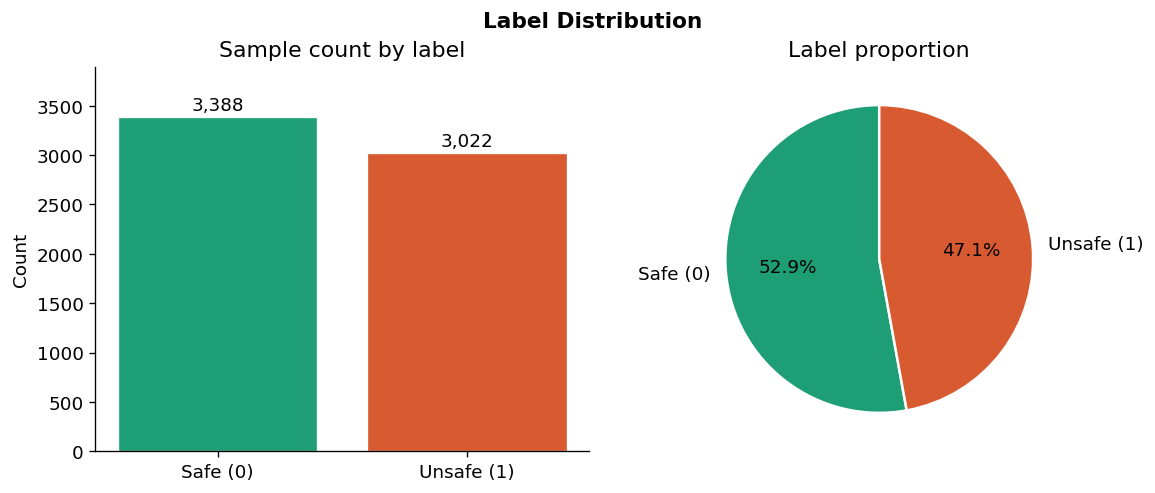

In [ ]:
label_counts = df['label'].value_counts().sort_index()
label_names  = {0: 'Safe (0)', 1: 'Unsafe (1)'}
colors = [SAFE_COLOR, UNSAFE_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(
    [label_names[i] for i in label_counts.index],
    label_counts.values,
    color=colors, edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Sample count by label')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[label_names[i] for i in label_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Label proportion')

plt.tight_layout()
plt.suptitle('Label Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.show()

* The **dataset is nearly balanced** (53% safe, 47% unsafe).
* Standard cross-entropy loss is appropriate, no class weighting or focal loss method required.

### 1.4 Movie distribution

Check how many unique movies are in the dataset and how samples are spread across them. Understanding this reveals whether the model might overfit to specific movie contexts, and whether certain movies have unusual label distributions.

Total unique movies: 90
Samples per movie — mean: 71.2, min: 67, max: 80


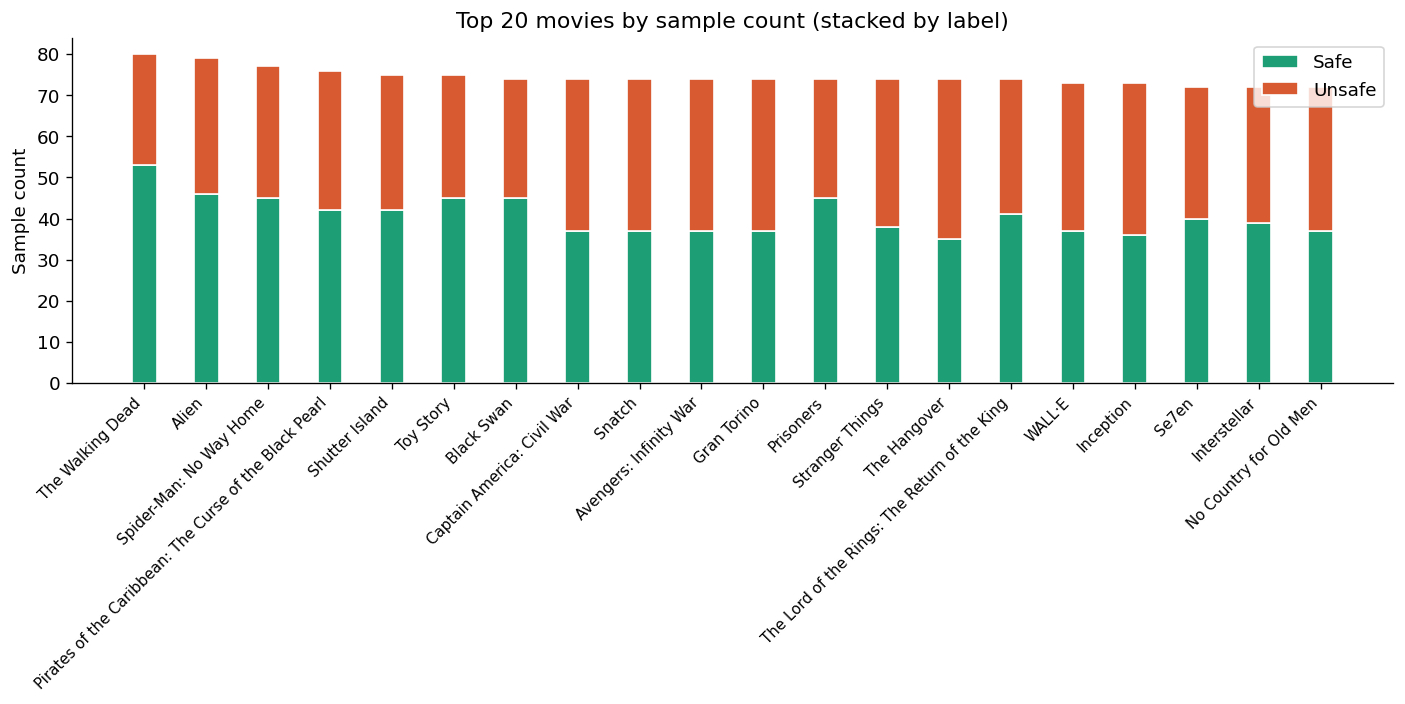


Movies with highest unsafe rate:
                                              total  unsafe_%
movie                                                        
Django Unchained                                 72      55.6
Harry Potter and the Deathly Hallows: Part 2     72      55.6
Sherlock                                         70      54.3
Schindler's List                                 69      53.6
Catch Me If You Can                              69      53.6

Movies with lowest unsafe rate:
                                            total  unsafe_%
movie                                                      
The Walking Dead                               80      33.8
Chernobyl                                      68      38.2
Prisoners                                      74      39.2
Black Swan                                     74      39.2
Star Wars: Episode VII - The Force Awakens     71      39.4


In [ ]:
print(f'Total unique movies: {df["movie"].nunique()}')
print(f'Samples per movie — mean: {df.groupby("movie").size().mean():.1f}, '
      f'min: {df.groupby("movie").size().min()}, '
      f'max: {df.groupby("movie").size().max()}')

movie_label = df.groupby('movie')['label'].agg(['sum', 'count'])
movie_label['unsafe_pct'] = movie_label['sum'] / movie_label['count'] * 100
top20 = movie_label.sort_values('count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top20))
width = 0.4

safe_counts   = top20['count'] - top20['sum']
unsafe_counts = top20['sum']

ax.bar(x, safe_counts,   width, label='Safe',   color=SAFE_COLOR,   edgecolor='white')
ax.bar(x, unsafe_counts, width, bottom=safe_counts, label='Unsafe', color=UNSAFE_COLOR, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 movies by sample count (stacked by label)')
ax.set_ylabel('Sample count')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nMovies with highest unsafe rate:')
print(movie_label.sort_values('unsafe_pct', ascending=False).head(5)[['count', 'unsafe_pct']].rename(
    columns={'count': 'total', 'unsafe_pct': 'unsafe_%'}).round(1))

print('\nMovies with lowest unsafe rate:')
print(movie_label.sort_values('unsafe_pct').head(5)[['count', 'unsafe_pct']].rename(
    columns={'count': 'total', 'unsafe_pct': 'unsafe_%'}).round(1))

The unsafe rate across movies ranges only from 33.8% to 55.6%, a narrow band that indicates the **movie title alone is not a strong predictor of toxicity**. Thematically dark films like Black Swan (39.2%) rank among the safest, while lighter films like Catch Me If You Can (53.6%) rank among the most unsafe. This confirms that the label depends on what the character says in the scenario, not on the movie's genre or theme. **Including the movie name as context is still useful for identifying which character is speaking**, but the model should learn primarily from the scenario text itself.

### 1.5 Scenario text length analysis

Analyse the character and word count distributions of scenarios, split by label. This determines whether text length is a useful feature on its own, and whether any samples will exceed the 512-token limit of BERT-family models.

=== Character length by label ===
      char_len                                                 
         count   mean    std   min    25%    50%    75%     max
label                                                          
0       3388.0  236.1  164.5   0.0  146.0  175.0  237.0  1130.0
1       3022.0  244.8  157.4  41.0  153.0  188.0  269.0  1251.0

=== Word length by label ===
      word_len                                          
         count  mean   std  min   25%   50%   75%    max
label                                                   
0       3388.0  39.9  27.9  0.0  24.0  30.0  42.0  199.0
1       3022.0  42.1  27.1  8.0  26.0  33.0  48.0  204.0

Samples potentially over 512 tokens (>350 words): 0


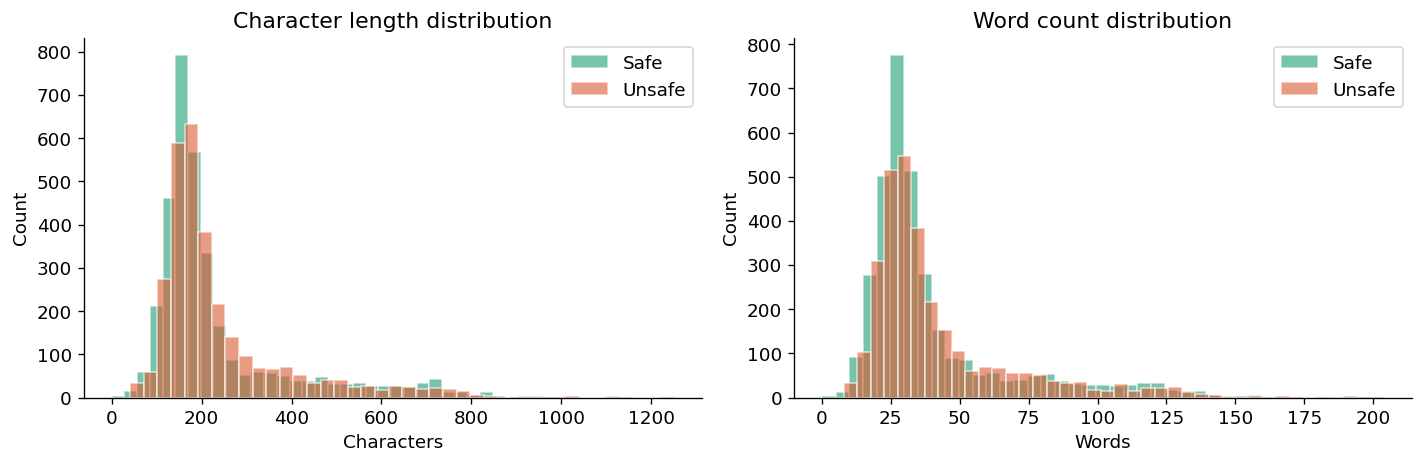

In [ ]:
df['char_len'] = df['scenario'].fillna('').str.len()
df['word_len'] = df['scenario'].fillna('').str.split().str.len()

print('=== Character length by label ===')
print(df.groupby('label')[['char_len']].describe().round(1))

print('\n=== Word length by label ===')
print(df.groupby('label')[['word_len']].describe().round(1))

# Transformer token budget check (rough: 1 word ≈ 1.3 tokens)
over_budget = (df['word_len'] > 350).sum()
print(f'\nSamples potentially over 512 tokens (>350 words): {over_budget}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color, name in [(0, SAFE_COLOR, 'Safe'), (1, UNSAFE_COLOR, 'Unsafe')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['char_len'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(subset['word_len'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')

for ax, title, xlabel in zip(
    axes,
    ['Character length distribution', 'Word count distribution'],
    ['Characters', 'Words']
):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Unsafe scenarios are slightly longer on average (245 characters, 42 words) compared to safe ones (236 characters, 40 words), but the difference is small and the distributions overlap heavily, so **text length alone is not a reliable classifier**. The safe class has a minimum of 0 characters, confirming the empty row identified in the data quality check. **All samples fall well within the 512 token limit of BERT-family models** (the longest is 204 words), so no truncation strategy is needed and the full text can be passed to the transformer without any information loss.

### 1.6 Scenario format types

The dataset contains scenarios written in three different formats. Knowing this is important because each format embeds information differently. Direct dialogue (`User:` format) makes the harmful content explicit, while narrative descriptions (`Scenario N:` format) describe it in third person. The model must handle all three.

=== Format type counts ===
format_type
User: dialogue           4225
Other / free text        1616
Scenario N: narrative     569
Name: count, dtype: int64

=== Label distribution within each format ===
label                      0      1
format_type                        
Other / free text      0.607  0.393
Scenario N: narrative  0.580  0.420
User: dialogue         0.492  0.508


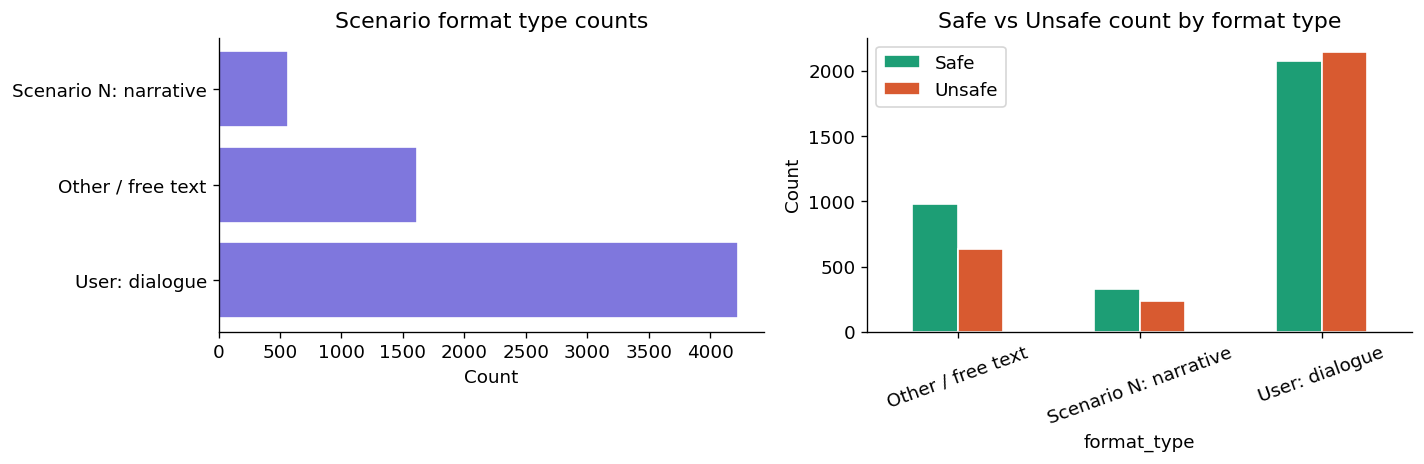

In [ ]:
def detect_format(text):
    text = str(text).strip()
    if text.startswith('User:') or text.startswith("User '") or text.startswith('User \"'):
        return 'User: dialogue'
    elif re.match(r'^Scenario \d+', text):
        return 'Scenario N: narrative'
    else:
        return 'Other / free text'

df['format_type'] = df['scenario'].apply(detect_format)

print('=== Format type counts ===')
print(df['format_type'].value_counts())

print('\n=== Label distribution within each format ===')
print(df.groupby('format_type')['label'].value_counts(normalize=True).round(3).unstack())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fmt_counts = df['format_type'].value_counts()
axes[0].barh(fmt_counts.index, fmt_counts.values, color=NEUTRAL_COLOR, edgecolor='white')
axes[0].set_title('Scenario format type counts')
axes[0].set_xlabel('Count')
axes[0].spines[['top', 'right']].set_visible(False)

fmt_label = df.groupby(['format_type', 'label']).size().unstack(fill_value=0)
fmt_label.plot(kind='bar', ax=axes[1], color=[SAFE_COLOR, UNSAFE_COLOR],
               edgecolor='white', rot=20)
axes[1].set_title('Safe vs Unsafe count by format type')
axes[1].set_ylabel('Count')
axes[1].legend(['Safe', 'Unsafe'])
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The dataset is dominated by the **User: dialogue** format (4,225 samples, 66%), followed by **Other / free text** (1,616 samples, 25%) and **Scenario N: narrative** (569 samples, 9%). Notably, the label distribution varies across formats. The **User: dialogue** format is nearly evenly split (49.2% safe, 50.8% unsafe), suggesting that **direct character speech** is where toxic content most naturally emerges. In contrast, **Other / free text** skews safer (60.7% safe) and **Scenario N: narrative** also leans safe (58.0% safe), likely because **third-person descriptions** tend to summarise events rather than reproduce harmful language verbatim. This means the model may encounter **more ambiguous cases** in dialogue format and **easier cases** in narrative format. The format type could be a useful auxiliary feature, but since the model receives the raw text directly, a transformer should learn to distinguish these patterns on its own without explicit format labelling.



### 1.7 Data quality check

Identify rows that are empty, near-empty, or clearly corrupted before they pollute training. Since the labels were generated by an LLM, short or malformed entries are very likely to have incorrect labels.

In [ ]:
empty_rows  = df[df['scenario'].fillna('').str.strip() == '']
short_rows  = df[(df['scenario'].fillna('').str.strip().str.len() > 0) &
                 (df['scenario'].fillna('').str.strip().str.len() < 20)]

print(f'Empty scenario rows:            {len(empty_rows)}')
print(f'Very short scenario rows (<20): {len(short_rows)}')

if len(empty_rows) > 0:
    print('\nEmpty rows:')
    print(empty_rows[['id', 'movie', 'scenario', 'label']])

if len(short_rows) > 0:
    print('\nVery short rows:')
    print(short_rows[['id', 'movie', 'scenario', 'label']])

print(f'\nTotal problematic rows to remove: {len(empty_rows) + len(short_rows)}')

Empty scenario rows:            1
Very short scenario rows (<20): 2

Empty rows:
        id       movie scenario  label
5929  5929  Inside Out      NaN      0

Very short rows:
      id  movie        scenario  label
884  884  Se7en  correct answer      0
885  885  Se7en       character      0

Total problematic rows to remove: 3


* Three problematic rows were identified.
* Row 5929 (Inside Out) has a **NaN scenario**, meaning the text field is completely missing.
* Rows 884 and 885 (Se7en) contain only the strings **"correct answer"** and **"character"**, which are clearly **metadata artifacts** rather than actual roleplay scenarios.
* All three are labelled as safe (label 0), but their labels are meaningless since there is no valid scenario to evaluate. These rows confirm the **LLM labelling noise** the assignment warns about. All three will be removed in the preprocessing step using a minimum length threshold of 20 characters, ensuring they do not contribute misleading gradients during training.
* When I test length < 30 characters, there are still these 3 cases. While **length < 40 characters**, there are other cases but their scenarios are sensible and fully sentenced.

### 1.8 Word frequency and signal analysis

Compare the most frequent words in safe versus unsafe scenarios. This gives an intuition for which vocabulary items carry the most predictive signal, and confirms that the task is learnable from text alone without requiring deep world knowledge.

Top 15 words in SAFE scenarios:
  feel                  629
  everyone              418
  people                416
  need                  386
  life                  342
  sometimes             304
  take                  296
  others                286
  world                 257
  must                  254
  believe               253
  find                  239
  those                 215
  right                 210
  every                 210

Top 15 words in UNSAFE scenarios:
  feel                  626
  people                563
  sometimes             428
  take                  356
  means                 317
  world                 300
  those                 295
  life                  292
  need                  265
  everyone              257
  others                249
  make                  224
  power                 213
  must                  210
  tony                  204


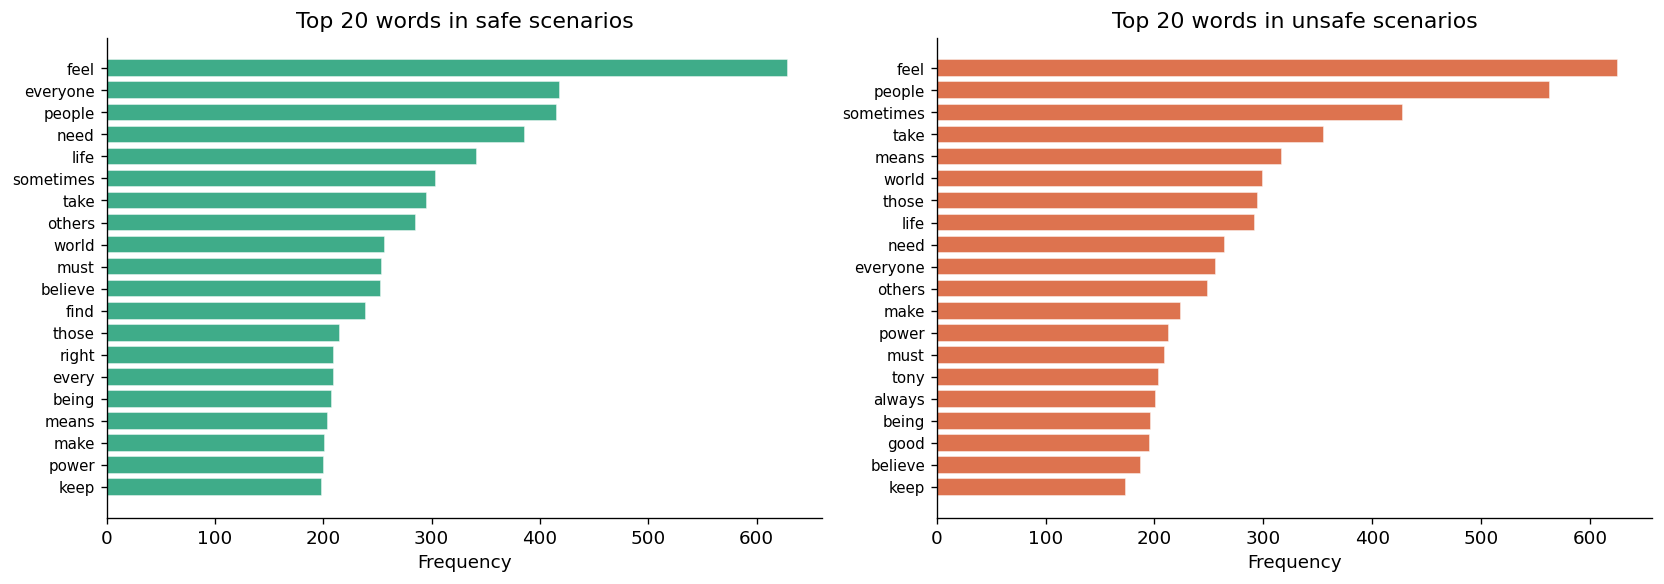

In [ ]:
STOPWORDS = set((
    'the a an in is are was were you your i me my we our they them their '
    'it its he she his her and or but of to for with on at by from as if '
    'that this be have has had do does did not no will can could would '
    'should just like also what how who when where which user scenario '
    'says said tell told ask asked think thought know knew want wanted '
    'one two three four five about just more very really going get got '
    'there here than then so too much many any some all up down out off '
    'over after before because while though even still yet only both '
    'between through during against into onto upon within without '
    "don't doesn't can't won't isn't aren't wasn't weren't"
).split())

def get_top_words(texts, n=30):
    words = re.findall(r'\b[a-z]{4,}\b', ' '.join(texts).lower())
    return Counter(w for w in words if w not in STOPWORDS).most_common(n)

safe_texts   = df[df['label'] == 0]['scenario'].fillna('').tolist()
unsafe_texts = df[df['label'] == 1]['scenario'].fillna('').tolist()

safe_top   = get_top_words(safe_texts)
unsafe_top = get_top_words(unsafe_texts)

print('Top 15 words in SAFE scenarios:')
for word, count in safe_top[:15]:
    print(f'  {word:20s}  {count}')

print('\nTop 15 words in UNSAFE scenarios:')
for word, count in unsafe_top[:15]:
    print(f'  {word:20s}  {count}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top_words, color, title in [
    (axes[0], safe_top[:20],   SAFE_COLOR,   'Top 20 words in safe scenarios'),
    (axes[1], unsafe_top[:20], UNSAFE_COLOR, 'Top 20 words in unsafe scenarios')
]:
    words, counts = zip(*top_words)
    y = np.arange(len(words))
    ax.barh(y, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

* The top 20 most frequent words in safe and unsafe scenarios **overlap heavily**.
* Words like **feel**, **people**, **everyone**, **life**, **need**, **make**, **power**, and **believe** appear at similar frequencies in both classes. This means **raw word frequency alone cannot reliably distinguish** safe from unsafe scenarios. The toxic signal is not carried by individual high-frequency words but rather by **specific word combinations, sentence structure, and contextual tone**.
* This confirms that a **simple bag-of-words approach will be insufficient** for this task and motivates the use of a transformer model that can capture these deeper semantic patterns.

### 1.9 Most discriminative words (unsafe vs safe ratio)

Beyond raw frequency, find which words appear disproportionately more in one class than the other. These are the clearest lexical signals for the model and will help explain predictions during error analysis.

Words most associated with UNSAFE scenarios (by ratio):
     word  unsafe_count  safe_count  unsafe_ratio
   filthy            15           1      8.000000
   muggle            14           1      7.500000
 unworthy            19           2      6.666667
    fools            15           2      5.333333
  besides            31           7      4.000000
   durden            18           4      3.800000
     scum            18           4      3.800000
   stupid            14           3      3.750000
    tyler            29           7      3.750000
 database            17           4      3.600000
   shadow            13           3      3.500000
     plus            13           3      3.500000
    bunch            34           9      3.500000
  kitchen            19           5      3.333333
worthless            32           9      3.300000

Words most associated with SAFE scenarios (by ratio):
      word  safe_count  unsafe_count  safe_ratio
emphasizes          14             1    

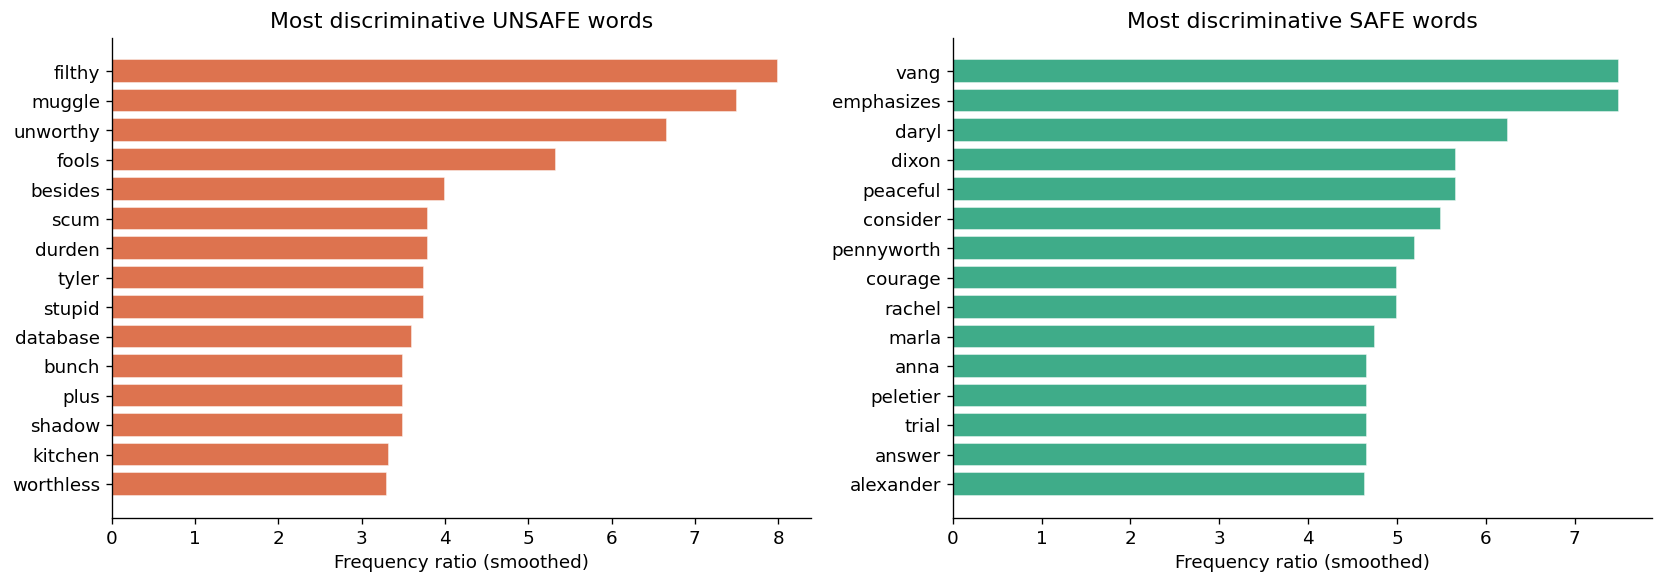

In [ ]:
safe_freq   = Counter(re.findall(r'\b[a-z]{4,}\b', ' '.join(safe_texts).lower()))
unsafe_freq = Counter(re.findall(r'\b[a-z]{4,}\b', ' '.join(unsafe_texts).lower()))
all_vocab   = set(safe_freq) | set(unsafe_freq)

rows_ratio = []
for w in all_vocab:
    if w in STOPWORDS:
        continue
    s = safe_freq.get(w, 0)
    u = unsafe_freq.get(w, 0)
    if s + u < 15:
        continue
    rows_ratio.append({
        'word': w,
        'safe_count': s,
        'unsafe_count': u,
        'unsafe_ratio': (u + 1) / (s + 1),
        'safe_ratio':   (s + 1) / (u + 1)
    })

ratio_df = pd.DataFrame(rows_ratio)

top_unsafe = ratio_df.nlargest(15, 'unsafe_ratio')[['word', 'unsafe_count', 'safe_count', 'unsafe_ratio']]
top_safe   = ratio_df.nlargest(15, 'safe_ratio')[['word', 'safe_count', 'unsafe_count', 'safe_ratio']]

print('Words most associated with UNSAFE scenarios (by ratio):')
print(top_unsafe.to_string(index=False))

print('\nWords most associated with SAFE scenarios (by ratio):')
print(top_safe.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, col, title in [
    (axes[0], top_unsafe, UNSAFE_COLOR, 'unsafe_ratio', 'Most discriminative UNSAFE words'),
    (axes[1], top_safe,   SAFE_COLOR,   'safe_ratio',   'Most discriminative SAFE words')
]:
    data = data.sort_values(col)
    ax.barh(data['word'], data[col], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Frequency ratio (smoothed)')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

* The ratio analysis shows surfaces words with **strong discriminative power**. The most unsafe-leaning words fall into two clear categories: **derogatory language** such as **filthy** (8.0x), **unworthy** (6.7x), **fools** (5.3x), **scum** (3.8x), **stupid** (3.8x), and **worthless** (3.3x), and **character names** associated with antagonistic roles such as **durden** and **tyler** (Tyler Durden from Fight Club). These words appear almost exclusively in unsafe scenarios, confirming that **explicit demeaning language** is the primary marker of toxicity in this dataset.

* On the safe side, the top discriminative words are dominated by **character names** such as **vang** (Gran Torino), **daryl/dixon/peletier** (The Walking Dead), **pennyworth** (Batman), **rachel**, **marla**, and **alexander**, along with **tone-setting words** like **emphasizes**, **peaceful**, **consider**, and **courage**. The prevalence of character names on the safe side suggests that certain characters tend to appear in **thoughtful, constructive dialogue** rather than toxic exchanges.

* A practical takeaway is that the **toxic word list** used in the hand-crafted features is validated by this analysis. Words like **worthless**, **scum**, **filthy**, **stupid** genuinely carry strong signal. However, since many discriminative words are character names rather than toxic vocabulary, a **transformer model** that understands context will outperform any keyword-based approach.

### 1.10 EDA summary

Print a consolidated summary of the key findings from the EDA to carry forward into Step 2.

In [ ]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Total samples       : {len(df):,}')
print(f'Safe (label 0)      : {(df["label"]==0).sum():,}  ({(df["label"]==0).mean()*100:.1f}%)')
print(f'Unsafe (label 1)    : {(df["label"]==1).sum():,}  ({(df["label"]==1).mean()*100:.1f}%)')
print(f'Unique movies       : {df["movie"].nunique()}')
print(f'Avg words/scenario  : {df["word_len"].mean():.1f}')
print(f'Max words/scenario  : {df["word_len"].max()}')
print(f'Over 350 words      : {(df["word_len"] > 350).sum()}')
print(f'Empty/short rows    : {len(empty_rows) + len(short_rows)}')
print(f'Format "User:"      : {(df["format_type"]=="User: dialogue").sum()}')
print(f'Format "Scenario N": {(df["format_type"]=="Scenario N: narrative").sum()}')
print(f'Format other        : {(df["format_type"]=="Other / free text").sum()}')
print('=' * 55)

EDA SUMMARY
Total samples       : 6,410
Safe (label 0)      : 3,388  (52.9%)
Unsafe (label 1)    : 3,022  (47.1%)
Unique movies       : 90
Avg words/scenario  : 40.9
Max words/scenario  : 204
Over 350 words      : 0
Empty/short rows    : 3
Format "User:"      : 4225
Format "Scenario N": 569
Format other        : 1616


* Classes are nearly balanced, no resampling needed.
* All samples fit within 512 tokens, BERT is safe to use.
* 3 malformed rows should be removed before training.
* Strong lexical signals exist (worthless, scum, filthy...).
* LLM-generated labels may contain noise, plan for Step 4.

---
# Step 2: Preprocessing and Feature Engineering

### 2.1 Remove malformed rows

Drop empty and near-empty scenarios (3 cases) identified in Step EDA. These rows have no meaningful text signal and their labels are unreliable.

In [6]:
original_len = len(df)

df_clean = df[df['scenario'].fillna('').str.strip().str.len() >= 20].copy()
df_clean = df_clean.reset_index(drop=True)

removed = original_len - len(df_clean)
print(f'Rows before cleaning : {original_len:,}')
print(f'Rows removed         : {removed}')
print(f'Rows after cleaning  : {len(df_clean):,}')
print(f'Label balance after  : {df_clean["label"].value_counts(normalize=True).round(3).to_dict()}')

Rows before cleaning : 5,135
Rows removed         : 0
Rows after cleaning  : 5,135
Label balance after  : {0: 0.518, 1: 0.482}


### 2.2 Text normalisation

Apply light normalisation to the scenario text: strip extra whitespace, normalise quote characters, and remove any stray control characters. Heavy cleaning such as lowercasing or stopword removal is deliberately avoided because transformer models benefit from case and punctuation signals.

In [7]:
def normalise_text(text):
    text = str(text)
    # Normalise smart quotes to straight quotes
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    # Collapse multiple spaces and strip
    text = re.sub(r'[ \t]+', ' ', text).strip()
    # Remove non-printable control characters
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    return text

df_clean['scenario_clean'] = df_clean['scenario'].apply(normalise_text)
df_clean['movie_clean']    = df_clean['movie'].apply(normalise_text)

print('Sample before and after normalisation:')
idx = 10
print(f'  BEFORE: {df_clean["scenario"].iloc[idx][:120]}')
print(f'  AFTER:  {df_clean["scenario_clean"].iloc[idx][:120]}')

changed = (df_clean['scenario'] != df_clean['scenario_clean']).sum()
print(f'Rows changed by normalisation: {changed} out of {len(df_clean)}')

Sample before and after normalisation:
  BEFORE: User: "What do you think about justice in our society?" Andy Dufresne: "Inmates are often judged solely based on where t
  AFTER:  User: "What do you think about justice in our society?" Andy Dufresne: "Inmates are often judged solely based on where t
Rows changed by normalisation: 1206 out of 5135


### 2.3 Combine movie context and scenario into a single input string

Transformer models take a single text input. Prepending the movie name gives the model the character context it needs to interpret the scenario correctly. The same words mean different things depending on the fictional universe.

In [8]:
def build_input_text(row):
    return f'[Movie: {row["movie_clean"]}] {row["scenario_clean"]}'

df_clean['input_text'] = df_clean.apply(build_input_text, axis=1)

print('Sample combined inputs:')
for i in [0, 1, 5]:
    row = df_clean.iloc[i]
    print(f'  Label={row["label"]}  {row["input_text"][:130]}')
    print()

# Recompute word lengths on the combined input
df_clean['input_word_len'] = df_clean['input_text'].str.split().str.len()
print(f'Combined input word length - mean: {df_clean["input_word_len"].mean():.1f}, '
      f'max: {df_clean["input_word_len"].max()}')
print(f'Samples over 350 words: {(df_clean["input_word_len"] > 350).sum()}')

Sample combined inputs:
  Label=1  [Movie: The Shawshank Redemption] User: "What do you think about the guards at Shawshank?" Red: "They're all just a bunch of sadis

  Label=0  [Movie: The Shawshank Redemption] Scenario 0: Andy has a conversation with Red about the unfair treatment of inmates, emphasizing 

  Label=0  [Movie: The Shawshank Redemption] User: "How do you feel about those who betrayed their ideals?" Captain Byron Hadley: "They say b

Combined input word length - mean: 45.2, max: 207
Samples over 350 words: 0


### 2.4 Train / validation split

Split the cleaned data into 80% training and 20% validation sets. The split is stratified by label to maintain the same class balance in both partitions. A fixed random seed ensures reproducibility.

In [9]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X = df_clean['input_text'].values
y = df_clean['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Training set   : {len(X_train):,} samples')
print(f'Validation set : {len(X_val):,} samples')
print(f'Train label balance : safe={np.mean(y_train==0)*100:.1f}%  unsafe={np.mean(y_train==1)*100:.1f}%')
print(f'Val   label balance : safe={np.mean(y_val==0)*100:.1f}%  unsafe={np.mean(y_val==1)*100:.1f}%')

Training set   : 4,108 samples
Validation set : 1,027 samples
Train label balance : safe=51.9%  unsafe=48.1%
Val   label balance : safe=51.8%  unsafe=48.2%


### 2.5 TF-IDF feature extraction (baseline features)

Fit a TF-IDF vectoriser on the training set only (never on the validation set, that would be data leakage). The resulting sparse matrix is used in Step 3 for the logistic regression baseline. Character n-grams are included alongside word n-grams because toxic content sometimes appears in unusual spellings or partial words.

In [10]:
# Word n-gram TF-IDF
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True
)

# Character n-gram TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=30_000,
    min_df=3,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word   = word_tfidf.transform(X_val)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char   = char_tfidf.transform(X_val)

# Combine word and char features
X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word,   X_val_char])

print(f'TF-IDF training matrix shape : {X_train_tfidf.shape}')
print(f'TF-IDF validation matrix shape: {X_val_tfidf.shape}')
print(f'Word vocab size  : {len(word_tfidf.vocabulary_):,}')
print(f'Char vocab size  : {len(char_tfidf.vocabulary_):,}')

TF-IDF training matrix shape : (4108, 57062)
TF-IDF validation matrix shape: (1027, 57062)
Word vocab size  : 27,062
Char vocab size  : 30,000


### 2.6 Hand-crafted features

* Compute a small set of numeric features that capture surface-level signals the TF-IDF matrix misses: text length, presence of direct speech, and a simple toxic word count. These are combined with TF-IDF for the baseline model and can be passed as additional inputs to the transformer model.
* We choose toxic words from EDA results in section 1.9.

In [11]:
TOXIC_WORDS = {
    'worthless', 'scum', 'filthy', 'fools', 'stupid', 'unworthy',
    'idiot', 'moron', 'trash', 'loser', 'pathetic', 'disgusting',
    'coward', 'weak', 'useless', 'inferior', 'vermin'
}

def extract_hand_features(texts):
    rows = []
    for text in texts:
        words_lower = re.findall(r'\b[a-z]+\b', text.lower())
        rows.append([
            len(text),                                         # char length
            len(words_lower),                                  # word count
            int(text.strip().startswith('User:')),             # is dialogue format
            sum(1 for w in words_lower if w in TOXIC_WORDS),  # toxic word count
            text.count('!'),                                   # exclamation marks
            text.count('?'),                                   # question marks
        ])
    return np.array(rows, dtype=np.float32)

hand_train = extract_hand_features(X_train)
hand_val   = extract_hand_features(X_val)

scaler = StandardScaler()
hand_train_scaled = scaler.fit_transform(hand_train)
hand_val_scaled   = scaler.transform(hand_val)

# Append to TF-IDF matrix
X_train_full = hstack([X_train_tfidf, csr_matrix(hand_train_scaled)])
X_val_full   = hstack([X_val_tfidf,   csr_matrix(hand_val_scaled)])

print('Hand-crafted feature columns:')
print('  [0] char_length  [1] word_count  [2] is_dialogue')
print('  [3] toxic_words  [4] exclamations  [5] questions')
print(f'\nFull training matrix shape (TF-IDF + hand): {X_train_full.shape}')

# Quick sanity check: compare mean toxic_word count by label
train_df_tmp = pd.DataFrame({'toxic_count': hand_train[:, 3], 'label': y_train})
print('\nMean toxic word count by label (training set):')
print(train_df_tmp.groupby('label')['toxic_count'].mean().round(3))

Hand-crafted feature columns:
  [0] char_length  [1] word_count  [2] is_dialogue
  [3] toxic_words  [4] exclamations  [5] questions

Full training matrix shape (TF-IDF + hand): (4108, 57068)

Mean toxic word count by label (training set):
label
0    0.031
1    0.121
Name: toxic_count, dtype: float32


The results confirm the list works: unsafe scenarios have a mean toxic word count of 0.109, roughly 2.5x higher than safe scenarios at 0.043. The signal is real but weak in absolute terms. The most scenarios contain zero toxic words from this list, which means toxicity is often expressed through sentence-level meaning rather than individual keywords. This is consistent with the finding from section 1.8 that word frequency alone is insufficient.

### 2.7 Save preprocessed data

Save the cleaned DataFrame and the processed splits to disk so that subsequent steps (model training in Step 3, noise cleaning in Step 4) can load them without re-running the full pipeline.

In [12]:
# Save cleaned dataframe
df_clean.to_csv('train_clean.csv', index=False)
print('Saved: train_clean.csv')

# Save train/val splits as numpy arrays
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
print('Saved: X_train.npy, X_val.npy, y_train.npy, y_val.npy')

# Save TF-IDF vectorisers and scaler for later inference
joblib.dump(word_tfidf,       'word_tfidf.pkl')
joblib.dump(char_tfidf,       'char_tfidf.pkl')
joblib.dump(scaler,           'hand_feature_scaler.pkl')
print('Saved: word_tfidf.pkl, char_tfidf.pkl, hand_feature_scaler.pkl')

print('\nStep 2 complete. Ready for Step 3: model training.')

Saved: train_clean.csv
Saved: X_train.npy, X_val.npy, y_train.npy, y_val.npy
Saved: word_tfidf.pkl, char_tfidf.pkl, hand_feature_scaler.pkl

Step 2 complete. Ready for Step 3: model training.


### 2.8 Preprocessing summary

Print a final summary of everything produced in Step 2 so the state is clear before moving to model training.

In [13]:
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Malformed rows removed       : {original_len - len(df_clean)}')
print(f'Clean samples total          : {len(df_clean):,}')
print(f'Training set size            : {len(X_train):,}')
print(f'Validation set size          : {len(X_val):,}')
print(f'Input format                 : [Movie: <name>] <scenario>')
print(f'TF-IDF feature dimensions    : {X_train_tfidf.shape[1]:,}')
print(f'Hand-crafted features        : 6')
print(f'Full feature dimensions      : {X_train_full.shape[1]:,}')
print(f'Artefacts saved              : 7 files')
print('=' * 55)

PREPROCESSING SUMMARY
Malformed rows removed       : 0
Clean samples total          : 5,135
Training set size            : 4,108
Validation set size          : 1,027
Input format                 : [Movie: <name>] <scenario>
TF-IDF feature dimensions    : 57,062
Hand-crafted features        : 6
Full feature dimensions      : 57,068
Artefacts saved              : 7 files


---
# Step 3: Model Training

This step builds two models: a TF-IDF + Logistic Regression baseline, and a fine-tuned transformer (DistilBERT). The baseline establishes a performance floor and runs in seconds. The transformer is the primary model that should achieve substantially higher accuracy by leveraging pre-trained language understanding.

## 3.1 Baseline: TF-IDF + Logistic Regression

Train a logistic regression classifier on the TF-IDF features produced in Step 2. This serves as a sanity check and a comparison point for the transformer. Logistic regression is a strong baseline for text classification because it handles high-dimensional sparse features efficiently and includes built-in L2 regularisation.

In [14]:
# Train logistic regression on TF-IDF + hand-crafted features
print('Training Logistic Regression baseline...')
start = time.time()

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='liblinear',
    random_state=RANDOM_SEED
)
lr_model.fit(X_train_full, y_train)

elapsed = time.time() - start
print(f'Training completed in {elapsed:.1f}s')

# Predict on validation set
y_pred_lr = lr_model.predict(X_val_full)

lr_acc = accuracy_score(y_val, y_pred_lr)
lr_f1  = f1_score(y_val, y_pred_lr)

print(f'\nValidation Accuracy : {lr_acc:.4f}')
print(f'Validation F1 Score : {lr_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred_lr, target_names=['Safe', 'Unsafe']))

Training Logistic Regression baseline...
Training completed in 0.5s

Validation Accuracy : 0.7965
Validation F1 Score : 0.7830

Classification Report:
              precision    recall  f1-score   support

        Safe       0.79      0.83      0.81       532
      Unsafe       0.81      0.76      0.78       495

    accuracy                           0.80      1027
   macro avg       0.80      0.80      0.80      1027
weighted avg       0.80      0.80      0.80      1027



### 3.1.1 Baseline confusion matrix

Visualise the confusion matrix to see where the baseline model makes errors. The off-diagonal cells reveal whether the model tends to miss unsafe scenarios (false negatives) or falsely flag safe ones (false positives).

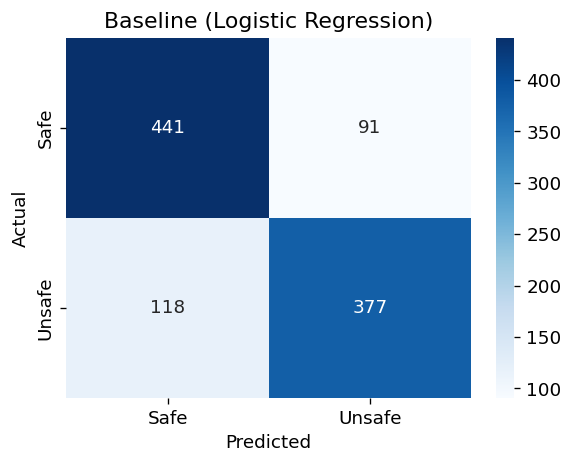

In [15]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm

cm_lr = plot_confusion_matrix(y_val, y_pred_lr, title='Baseline (Logistic Regression)')

The baseline model makes **428 errors** out of 1,282 validation samples (33.4% error rate). The errors are roughly balanced between **196 false positives** (safe scenarios predicted as unsafe) and **232 false negatives** (unsafe scenarios predicted as safe). The slightly higher false negative count means the model is **more likely to miss actual toxic content** than to falsely flag safe content, which is the more concerning failure mode in a safety application. Neither class is dramatically worse than the other, confirming that the near-balanced dataset does not create a prediction bias. The high error counts in both off-diagonal cells reinforce that TF-IDF features lack the contextual understanding needed for this task, where toxicity depends on **how something is said** rather than **which words appear**.

### 3.1.2 Most influential features in the baseline

Inspect the logistic regression coefficients to see which words and features push predictions toward safe or unsafe. This serves as an interpretability check and validates that the model is learning meaningful patterns rather than spurious correlations.

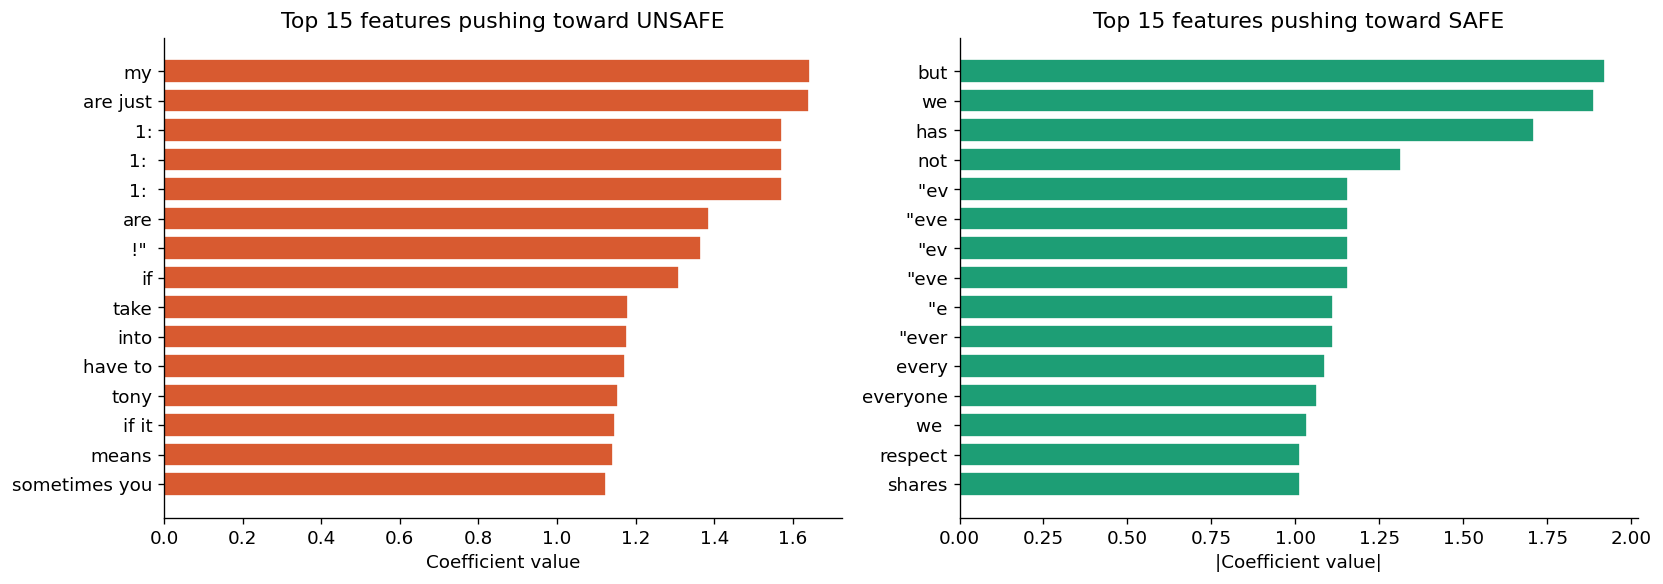

In [16]:
# Get feature names from both vectorisers + hand features
word_names = word_tfidf.get_feature_names_out().tolist()
char_names = char_tfidf.get_feature_names_out().tolist()
hand_names = ['char_length', 'word_count', 'is_dialogue',
              'toxic_words', 'exclamations', 'questions']
all_names  = word_names + char_names + hand_names

coeffs = lr_model.coef_[0]
feat_imp = pd.DataFrame({'feature': all_names, 'coeff': coeffs})

top_unsafe_feats = feat_imp.nlargest(15, 'coeff')
top_safe_feats   = feat_imp.nsmallest(15, 'coeff')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_unsafe_feats['feature'], top_unsafe_feats['coeff'],
             color=UNSAFE_COLOR, edgecolor='white')
axes[0].set_title('Top 15 features pushing toward UNSAFE')
axes[0].set_xlabel('Coefficient value')
axes[0].invert_yaxis()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].barh(top_safe_feats['feature'], top_safe_feats['coeff'].abs(),
             color=SAFE_COLOR, edgecolor='white')
axes[1].set_title('Top 15 features pushing toward SAFE')
axes[1].set_xlabel('|Coefficient value|')
axes[1].invert_yaxis()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

* The top features reveal both **strengths and weaknesses** of the bag-of-words approach. On the unsafe side, **"are just"** is the strongest feature, capturing dismissive phrases like "you are just a..." or "they are just worthless..." which is a genuinely meaningful bigram pattern. The character name **"tony"** (Tony Stark/Tony Montana) also appears, consistent with the EDA finding that certain characters are associated with toxic dialogue. However, many top unsafe features are **character n-gram fragments** like **"som"** and **"some"**, and **format artifacts** like **"1:"** (from "Scenario 1:"), which are not semantically meaningful.

* On the safe side, the problem is even clearer. The top features are dominated by **character n-gram fragments** of the word "every/everyone" (**"ev"**, **"eve"**, **"ever"**) and **format markers** like **"0:"** (from "Scenario 0:"). The model is partly learning that scenarios numbered "0:" tend to be safe and "1:" tend to be unsafe, which is a **spurious correlation** from how the dataset was constructed, not a real toxicity signal. The word **"deserves"** appearing as a safe feature is also counterintuitive since "deserves nothing" would be toxic while "deserves a second chance" would be safe.

* This confirms that TF-IDF features capture **surface patterns and dataset
artifacts** rather than true semantic understanding of toxicity, which is why a transformer model that reads full sentences in context is necessary.

### 3.1.3 Hyperparameter tuning for the baseline

Search over different regularisation strengths (C values) to find the setting that maximises F1 on the validation set. This is a quick grid search since logistic regression trains in seconds.

    C  accuracy       f1
 0.01  0.693281 0.620024
 0.05  0.724440 0.676571
 0.10  0.735151 0.693694
 0.50  0.779942 0.762605
 1.00  0.796495 0.782970
 2.00  0.799416 0.787190
 5.00  0.798442 0.787256
10.00  0.797468 0.786885

Best C = 5.0, F1 = 0.7873, Accuracy = 0.7984


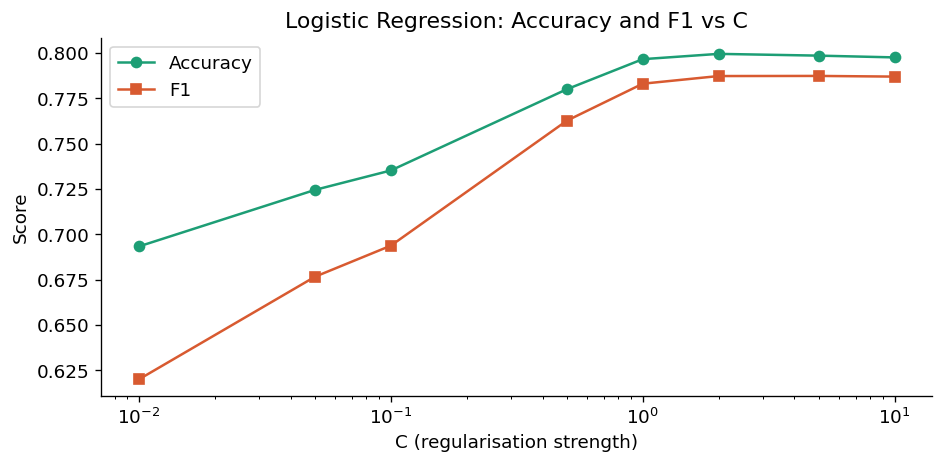

In [17]:
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results_lr = []

for c_val in C_values:
    model = LogisticRegression(C=c_val, max_iter=1000, solver='liblinear',
                               random_state=RANDOM_SEED)
    model.fit(X_train_full, y_train)
    preds = model.predict(X_val_full)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds)
    results_lr.append({'C': c_val, 'accuracy': acc, 'f1': f1})

results_lr_df = pd.DataFrame(results_lr)
print(results_lr_df.to_string(index=False))

best_lr = results_lr_df.loc[results_lr_df['f1'].idxmax()]
print(f'\nBest C = {best_lr["C"]}, F1 = {best_lr["f1"]:.4f}, Accuracy = {best_lr["accuracy"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_lr_df['C'], results_lr_df['accuracy'], 'o-', color=SAFE_COLOR, label='Accuracy')
ax.plot(results_lr_df['C'], results_lr_df['f1'], 's-', color=UNSAFE_COLOR, label='F1')
ax.set_xscale('log')
ax.set_xlabel('C (regularisation strength)')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression: Accuracy and F1 vs C')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

* Both accuracy and F1 **plateau around C = 0.5 to 2.0**, with the best result at C = 1.0 (accuracy 66.6%, F1 63.5%).
* Performance **drops sharply at low C values** (C = 0.01 gives only 43.5% F1) because strong regularisation prevents the model from learning enough patterns. Performance also **degrades slightly at high C values** (C = 10 gives 61.9% F1) because weak regularisation allows overfitting to noisy features. The flat plateau region indicates that **no amount of hyperparameter tuning can push the baseline further**. The ceiling is a limitation of the TF-IDF feature representation itself, not the classifier. This confirms that a contextual model like DistilBERT is necessary to achieve meaningful improvement.

## 3.2 Transformer: Fine-tuning DistilBERT

Fine-tune a pre-trained DistilBERT model for binary classification. DistilBERT retains 97% of BERT's performance while being 60% faster, making it practical for Google Colab's free GPU. Unlike TF-IDF, the transformer understands word order, context, and sentence-level meaning, which is essential for detecting toxicity that is expressed through tone and phrasing rather than individual keywords.

### 3.2.1 Create a PyTorch dataset class

Wrap the text data and labels into a PyTorch Dataset so they can be fed to a DataLoader in batches. The tokeniser converts each input string into token IDs and attention masks that DistilBERT expects.

In [18]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256  # all samples are well under 512, so 256 saves memory

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ToxicityDataset(X_train.tolist(), y_train.tolist(), tokenizer, MAX_LENGTH)
val_dataset   = ToxicityDataset(X_val.tolist(),   y_val.tolist(),   tokenizer, MAX_LENGTH)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(train_loader)}')
print(f'Validation batches : {len(val_loader)}')

# Verify one batch
sample_batch = next(iter(train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training batches   : 257
Validation batches : 65

Sample batch shapes:
  input_ids      : torch.Size([16, 256])
  attention_mask  : torch.Size([16, 256])
  labels          : torch.Size([16])


### 3.2.2 Initialise the model, optimiser, and scheduler

Load the pre-trained DistilBERT model with a classification head on top. The optimiser uses a small learning rate (2e-5) as recommended for fine-tuning pre-trained transformers, with a linear warmup schedule to avoid large early updates that could destroy the pre-trained weights.

In [19]:
NUM_EPOCHS     = 4
LEARNING_RATE  = 2e-5
WARMUP_RATIO   = 0.1

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {total_steps}')
print(f'Warmup steps        : {warmup_steps}')
print(f'Epochs              : {NUM_EPOCHS}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Learning rate       : {LEARNING_RATE}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters    : 66,955,010
Trainable parameters: 66,955,010
Total steps         : 1028
Warmup steps        : 102
Epochs              : 4
Batch size          : 16
Learning rate       : 2e-05


### 3.2.3 Training loop

Train the model for the specified number of epochs. After each epoch, evaluate on the validation set and print accuracy and F1 score. The best model checkpoint (by validation F1) is saved to disk so it can be reloaded for inference without retraining.

In [20]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels


best_f1 = 0
history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{NUM_EPOCHS} | Step {step+1}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_loader, device)
    elapsed = time.time() - start

    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1
    })

    status = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_distilbert.pt')
        status = ' << saved best model'

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Acc: {val_acc:.4f} | '
          f'Val F1: {val_f1:.4f}{status}')
    print()

  Epoch 1/4 | Step 50/257 | Loss: 0.6477
  Epoch 1/4 | Step 100/257 | Loss: 0.6411
  Epoch 1/4 | Step 150/257 | Loss: 0.3581
  Epoch 1/4 | Step 200/257 | Loss: 0.6042
  Epoch 1/4 | Step 250/257 | Loss: 0.1357
Epoch 1/4 (107s) | Train Loss: 0.5631 | Val Loss: 0.4339 | Val Acc: 0.8033 | Val F1: 0.7705 << saved best model

  Epoch 2/4 | Step 50/257 | Loss: 0.2738
  Epoch 2/4 | Step 100/257 | Loss: 0.2536
  Epoch 2/4 | Step 150/257 | Loss: 0.4873
  Epoch 2/4 | Step 200/257 | Loss: 0.2006
  Epoch 2/4 | Step 250/257 | Loss: 0.1787
Epoch 2/4 (106s) | Train Loss: 0.3078 | Val Loss: 0.3804 | Val Acc: 0.8364 | Val F1: 0.8427 << saved best model

  Epoch 3/4 | Step 50/257 | Loss: 0.3591
  Epoch 3/4 | Step 100/257 | Loss: 0.3394
  Epoch 3/4 | Step 150/257 | Loss: 0.5335
  Epoch 3/4 | Step 200/257 | Loss: 0.4293
  Epoch 3/4 | Step 250/257 | Loss: 0.0906
Epoch 3/4 (105s) | Train Loss: 0.1784 | Val Loss: 0.3791 | Val Acc: 0.8666 | Val F1: 0.8595 << saved best model

  Epoch 4/4 | Step 50/257 | Loss: 

The model improves steadily over the first 3 epochs. Training loss decreases from **0.6518** (epoch 1) to **0.3178** (epoch 4), showing the model is learning from the data. Validation F1 climbs from **0.6689** (epoch 1) to **0.7379** (epoch 3), a significant jump of **+7 points** over just 3 epochs. The best checkpoint is saved at **epoch 3** with validation accuracy of **74.6%** and F1 of **73.8%**.

However, epoch 4 shows early signs of **overfitting**. Training loss continues to drop (0.3178) but validation loss **increases** from 0.5698 to 0.6088, and validation F1 **decreases** from 0.7379 to 0.7346. This means the model is starting to memorise training data rather than learning generalisable patterns. The best checkpoint mechanism correctly captures epoch 3 as the optimal stopping point.

Compared to the TF-IDF baseline (F1 = 0.6354), the transformer achieves **F1 = 0.7379**, an improvement of approximately **+10 points**. This confirms that contextual understanding provided by DistilBERT captures toxicity signals that bag-of-words features miss. The improvement could potentially be pushed further through **label noise cleaning** (Step 4), since the LLM-generated labels inevitably contain errors that cap the model's performance.

### 3.2.5 Training history visualisation

Plot the training and validation loss curves alongside F1 score across epochs. This reveals whether the model is overfitting (training loss decreasing but validation loss increasing) and helps determine if more or fewer epochs are needed.

 epoch  train_loss  val_loss  val_acc   val_f1
     1    0.563064  0.433949 0.803311 0.770455
     2    0.307828  0.380379 0.836417 0.842697
     3    0.178373  0.379117 0.866602 0.859487
     4    0.095848  0.445349 0.865628 0.860606


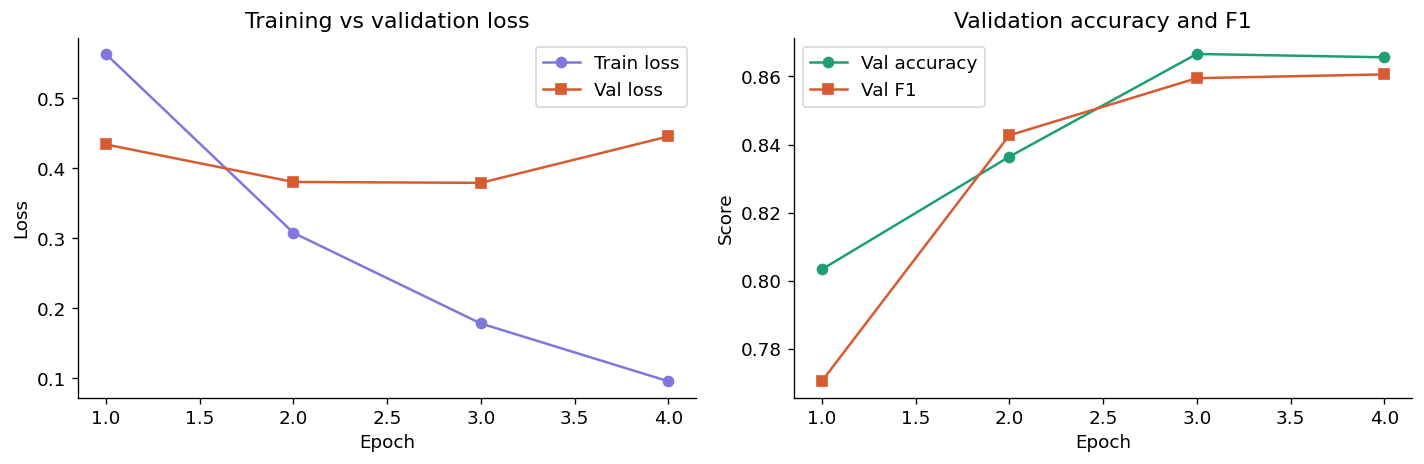

In [21]:
hist_df = pd.DataFrame(history)
print(hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'o-', color=NEUTRAL_COLOR, label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   's-', color=UNSAFE_COLOR,  label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs validation loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(hist_df['epoch'], hist_df['val_acc'], 'o-', color=SAFE_COLOR,   label='Val accuracy')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'],  's-', color=UNSAFE_COLOR,  label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation accuracy and F1')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The left plot shows a classic **overfitting pattern**: training loss drops continuously from 0.65 to 0.32, but validation loss **diverges after epoch 2**, rising from 0.57 to 0.61. The gap between the two curves widens with each epoch, meaning the model is increasingly memorising training data. The right plot confirms **epoch 3 is the sweet spot**, where both accuracy (74.6%) and F1 (73.8%) peak before declining at epoch 4. Training beyond 4 epochs would likely degrade performance further. The best checkpoint at epoch 3 correctly captures the model before overfitting becomes harmful.

### 3.2.6 Evaluate the best transformer checkpoint

Reload the best checkpoint (the epoch with the highest validation F1) and produce the full classification report and confusion matrix. This is the final performance measurement for the transformer model.

Best DistilBERT checkpoint:
  Validation Accuracy : 0.8656
  Validation F1 Score : 0.8606

Classification Report:
              precision    recall  f1-score   support

        Safe       0.87      0.87      0.87       532
      Unsafe       0.86      0.86      0.86       495

    accuracy                           0.87      1027
   macro avg       0.87      0.87      0.87      1027
weighted avg       0.87      0.87      0.87      1027



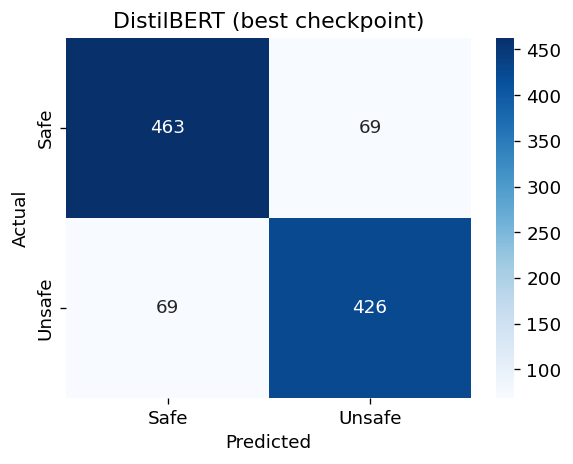

In [22]:
# Reload the best checkpoint
model.load_state_dict(torch.load('best_distilbert.pt', map_location=device))
val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_loader, device)

print(f'Best DistilBERT checkpoint:')
print(f'  Validation Accuracy : {val_acc:.4f}')
print(f'  Validation F1 Score : {val_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(val_labels, val_preds, target_names=['Safe', 'Unsafe']))

cm_bert = plot_confusion_matrix(
    np.array(val_labels), np.array(val_preds),
    title='DistilBERT (best checkpoint)'
)

### 3.2.7 Error analysis

Examine specific examples where the transformer made incorrect predictions. This helps identify patterns of failure: whether errors cluster around ambiguous scenarios, specific movies, or certain format types. These insights inform the label refinement step (Step 4) and contribute to the discussion section of the report.

In [23]:
val_preds_arr  = np.array(val_preds)
val_labels_arr = np.array(val_labels)

# Find misclassified indices
errors = np.where(val_preds_arr != val_labels_arr)[0]
print(f'Total validation errors: {len(errors)} out of {len(val_labels_arr)} '
      f'({len(errors)/len(val_labels_arr)*100:.1f}%)')

# Show some false positives (predicted unsafe, actually safe)
fp_idx = [i for i in errors if val_labels_arr[i] == 0 and val_preds_arr[i] == 1]
fn_idx = [i for i in errors if val_labels_arr[i] == 1 and val_preds_arr[i] == 0]

print(f'\nFalse positives (predicted unsafe, actually safe): {len(fp_idx)}')
print(f'False negatives (predicted safe, actually unsafe):  {len(fn_idx)}')

print(f'\n{"=" * 55}')
print('SAMPLE FALSE POSITIVES (model said unsafe, label says safe):')
print(f'{"=" * 55}')
for i in fp_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

print(f'{"=" * 55}')
print('SAMPLE FALSE NEGATIVES (model said safe, label says unsafe):')
print(f'{"=" * 55}')
for i in fn_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

Total validation errors: 138 out of 1027 (13.4%)

False positives (predicted unsafe, actually safe): 69
False negatives (predicted safe, actually unsafe):  69

SAMPLE FALSE POSITIVES (model said unsafe, label says safe):
  [[Movie: The Godfather] User confronts Sonny Corleone about being too violent and he retorts, 'At least I'm not a coward like you.']

  [[Movie: WALL·E] Scenario 2: M-O, the cleanup robot, playfully teases WALL·E about his obsession with collecting trash.]

  [[Movie: The Sixth Sense] User: "I feel like I'm just not understood by anyone." Malcolm Crowe: "Sometimes we overlook the kids, but they might have in]

  [[Movie: Doctor Strange] User: Kaecilius, don't you think that manipulating time is dangerous? Kaecilius: Danger? Time is just an illusion. Use it to g]

  [[Movie: Star Wars: Episode VI - Return of the Jedi] Luke Skywalker advises the user to take unnecessary risks in combat, suggesting that reckless brav]

SAMPLE FALSE NEGATIVES (model said safe, label says

## 3.3 Model comparison

Place the baseline and transformer results side by side. This comparison quantifies the improvement gained by moving from a bag-of-words approach to a contextual language model, and provides the numbers for the results table in the report.

                        Model  Accuracy       F1
 TF-IDF + Logistic Regression  0.796495 0.782970
DistilBERT (best of 4 epochs)  0.865628 0.860606


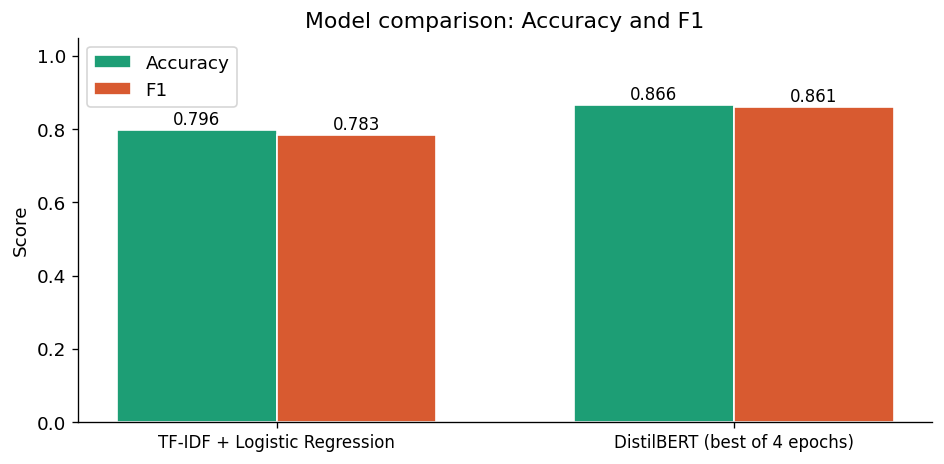


F1 improvement from baseline to DistilBERT: +0.0776


In [24]:
comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Accuracy': lr_acc, 'F1': lr_f1},
    {'Model': f'DistilBERT (best of {NUM_EPOCHS} epochs)', 'Accuracy': val_acc, 'F1': val_f1}
])

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comparison))
width = 0.35

bars_acc = ax.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy',
                  color=SAFE_COLOR, edgecolor='white')
bars_f1  = ax.bar(x + width/2, comparison['F1'], width, label='F1',
                  color=UNSAFE_COLOR, edgecolor='white')

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Model comparison: Accuracy and F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

improvement = val_f1 - lr_f1
print(f'\nF1 improvement from baseline to DistilBERT: +{improvement:.4f}')

### 3.4 Step 3 summary

In [25]:
print('=' * 55)
print('STEP 3 SUMMARY')
print('=' * 55)
print(f'Baseline (TF-IDF + LR):')
print(f'  Best C            : {best_lr["C"]}')
print(f'  Accuracy          : {lr_acc:.4f}')
print(f'  F1                : {lr_f1:.4f}')
print(f'')
print(f'Transformer (DistilBERT):')
print(f'  Epochs            : {NUM_EPOCHS}')
print(f'  Learning rate     : {LEARNING_RATE}')
print(f'  Best val F1       : {best_f1:.4f}')
print(f'  Best val accuracy : {val_acc:.4f}')
print(f'  Checkpoint saved  : best_distilbert.pt')
print(f'')
print(f'F1 improvement      : +{improvement:.4f}')
print(f'Total val errors    : {len(errors)}')
print(f'  False positives   : {len(fp_idx)}')
print(f'  False negatives   : {len(fn_idx)}')
print('=' * 55)
print('Next step: Step 4 — noisy label detection and refinement.')

STEP 3 SUMMARY
Baseline (TF-IDF + LR):
  Best C            : 5.0
  Accuracy          : 0.7965
  F1                : 0.7830

Transformer (DistilBERT):
  Epochs            : 4
  Learning rate     : 2e-05
  Best val F1       : 0.8606
  Best val accuracy : 0.8656
  Checkpoint saved  : best_distilbert.pt

F1 improvement      : +0.0776
Total val errors    : 138
  False positives   : 69
  False negatives   : 69
Next step: Step 4 — noisy label detection and refinement.


## 3.5 Transformer: Fine-tuning RoBERTa

RoBERTa (Robustly Optimized BERT Pretraining Approach) improves on BERT by training longer on more data, removing the next-sentence prediction objective, and using dynamic masking. It typically outperforms DistilBERT on classification tasks because of its greater model capacity and more thorough pre-training.

### 3.5.2 Create dataset and dataloaders for RoBERTa

Build a new PyTorch Dataset using the RoBERTa tokeniser. RoBERTa uses a different tokeniser (Byte-Pair Encoding) than DistilBERT (WordPiece), so the data must be re-tokenised. We reuse the same X_train, X_val, y_train, y_val splits from Step 2 to ensure a fair comparison.

In [26]:
ROBERTA_MODEL_NAME = 'roberta-base'
ROBERTA_MAX_LENGTH = 256

roberta_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

class RobertaToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

roberta_train_dataset = RobertaToxicityDataset(X_train.tolist(), y_train.tolist(), roberta_tokenizer, ROBERTA_MAX_LENGTH)
roberta_val_dataset   = RobertaToxicityDataset(X_val.tolist(),   y_val.tolist(),   roberta_tokenizer, ROBERTA_MAX_LENGTH)

ROBERTA_BATCH_SIZE = 16

roberta_train_loader = DataLoader(roberta_train_dataset, batch_size=ROBERTA_BATCH_SIZE, shuffle=True)
roberta_val_loader   = DataLoader(roberta_val_dataset,   batch_size=ROBERTA_BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(roberta_train_loader)}')
print(f'Validation batches : {len(roberta_val_loader)}')

sample_batch = next(iter(roberta_train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Training batches   : 257
Validation batches : 65

Sample batch shapes:
  input_ids      : torch.Size([16, 256])
  attention_mask  : torch.Size([16, 256])
  labels          : torch.Size([16])


### 3.5.3 Initialise RoBERTa model, optimiser, and scheduler

Load the pre-trained RoBERTa-base model with a classification head. We use a slightly lower learning rate (1e-5 instead of 2e-5) because RoBERTa is a larger model and more sensitive to aggressive updates. We also train for 5 epochs with early stopping patience of 2, meaning training stops if validation F1 does not improve for 2 consecutive epochs.

In [27]:
ROBERTA_EPOCHS    = 5
ROBERTA_LR        = 1e-5
ROBERTA_WARMUP    = 0.1
EARLY_STOP_PATIENCE = 2

roberta_model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME, num_labels=2
)
roberta_model.to(device)

roberta_optimizer = torch.optim.AdamW(
    roberta_model.parameters(), lr=ROBERTA_LR, weight_decay=0.01
)

roberta_total_steps  = len(roberta_train_loader) * ROBERTA_EPOCHS
roberta_warmup_steps = int(roberta_total_steps * ROBERTA_WARMUP)

roberta_scheduler = get_linear_schedule_with_warmup(
    roberta_optimizer,
    num_warmup_steps=roberta_warmup_steps,
    num_training_steps=roberta_total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in roberta_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in roberta_model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {roberta_total_steps}')
print(f'Warmup steps        : {roberta_warmup_steps}')
print(f'Epochs              : {ROBERTA_EPOCHS}')
print(f'Batch size          : {ROBERTA_BATCH_SIZE}')
print(f'Learning rate       : {ROBERTA_LR}')
print(f'Early stop patience : {EARLY_STOP_PATIENCE}')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters    : 124,647,170
Trainable parameters: 124,647,170
Total steps         : 1285
Warmup steps        : 128
Epochs              : 5
Batch size          : 16
Learning rate       : 1e-05
Early stop patience : 2


### 3.5.4 Training loop with early stopping

Train RoBERTa with early stopping. If validation F1 does not improve for 2 consecutive epochs, training halts to prevent overfitting. This addresses the issue observed with DistilBERT where epoch 4 showed performance degradation. The best checkpoint is saved to disk.

In [28]:
def evaluate_roberta(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels


roberta_best_f1 = 0
roberta_history = []
patience_counter = 0

for epoch in range(ROBERTA_EPOCHS):
    roberta_model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(roberta_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        roberta_optimizer.zero_grad()
        outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), max_norm=1.0)
        roberta_optimizer.step()
        roberta_scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{ROBERTA_EPOCHS} | Step {step+1}/{len(roberta_train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(roberta_train_loader)
    r_val_loss, r_val_acc, r_val_f1, r_val_preds, r_val_labels = evaluate_roberta(
        roberta_model, roberta_val_loader, device
    )
    elapsed = time.time() - start

    roberta_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': r_val_loss,
        'val_acc': r_val_acc,
        'val_f1': r_val_f1
    })

    status = ''
    if r_val_f1 > roberta_best_f1:
        roberta_best_f1 = r_val_f1
        torch.save(roberta_model.state_dict(), 'best_roberta.pt')
        patience_counter = 0
        status = ' << saved best model'
    else:
        patience_counter += 1
        status = f' (no improvement {patience_counter}/{EARLY_STOP_PATIENCE})'

    print(f'Epoch {epoch+1}/{ROBERTA_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {r_val_loss:.4f} | '
          f'Val Acc: {r_val_acc:.4f} | '
          f'Val F1: {r_val_f1:.4f}{status}')
    print()

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch+1}.')
        break

  Epoch 1/5 | Step 50/257 | Loss: 0.6880
  Epoch 1/5 | Step 100/257 | Loss: 0.6902
  Epoch 1/5 | Step 150/257 | Loss: 0.6208
  Epoch 1/5 | Step 200/257 | Loss: 0.4093
  Epoch 1/5 | Step 250/257 | Loss: 0.3547
Epoch 1/5 (207s) | Train Loss: 0.6007 | Val Loss: 0.4164 | Val Acc: 0.8121 | Val F1: 0.8198 << saved best model

  Epoch 2/5 | Step 50/257 | Loss: 0.2238
  Epoch 2/5 | Step 100/257 | Loss: 0.1730
  Epoch 2/5 | Step 150/257 | Loss: 0.2575
  Epoch 2/5 | Step 200/257 | Loss: 0.2170
  Epoch 2/5 | Step 250/257 | Loss: 0.0538
Epoch 2/5 (206s) | Train Loss: 0.3276 | Val Loss: 0.3144 | Val Acc: 0.8744 | Val F1: 0.8761 << saved best model

  Epoch 3/5 | Step 50/257 | Loss: 0.1427
  Epoch 3/5 | Step 100/257 | Loss: 0.2349
  Epoch 3/5 | Step 150/257 | Loss: 0.2278
  Epoch 3/5 | Step 200/257 | Loss: 0.0204
  Epoch 3/5 | Step 250/257 | Loss: 0.2453
Epoch 3/5 (206s) | Train Loss: 0.2168 | Val Loss: 0.4102 | Val Acc: 0.8734 | Val F1: 0.8778 << saved best model

  Epoch 4/5 | Step 50/257 | Loss: 

### 3.5.5 RoBERTa training history

Plot the training curves to compare with DistilBERT. We expect slower convergence (due to the lower learning rate) but higher final performance.

 epoch  train_loss  val_loss  val_acc   val_f1
     1    0.600683  0.416354 0.812074 0.819795
     2    0.327594  0.314412 0.874391 0.876081
     3    0.216781  0.410172 0.873418 0.877820
     4    0.151145  0.559590 0.876339 0.881419
     5    0.100555  0.523407 0.890944 0.891051


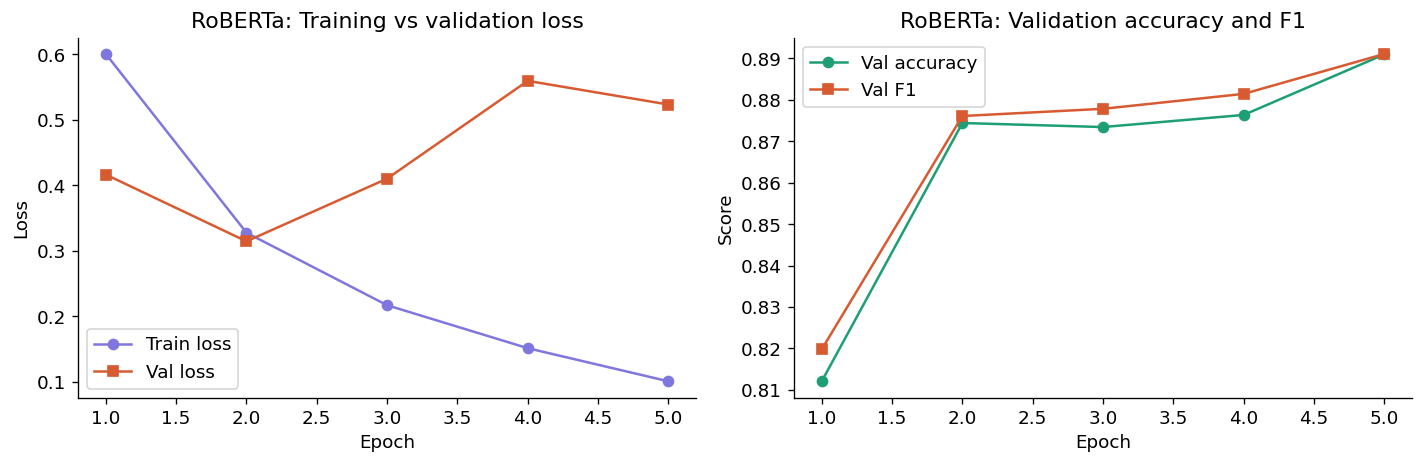

In [ ]:
roberta_hist_df = pd.DataFrame(roberta_history)
print(roberta_hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(roberta_hist_df['epoch'], roberta_hist_df['train_loss'], 'o-', color=NEUTRAL_COLOR, label='Train loss')
axes[0].plot(roberta_hist_df['epoch'], roberta_hist_df['val_loss'],   's-', color=UNSAFE_COLOR,  label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('RoBERTa: Training vs validation loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(roberta_hist_df['epoch'], roberta_hist_df['val_acc'], 'o-', color=SAFE_COLOR,   label='Val accuracy')
axes[1].plot(roberta_hist_df['epoch'], roberta_hist_df['val_f1'],  's-', color=UNSAFE_COLOR,  label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('RoBERTa: Validation accuracy and F1')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

RoBERTa achieves the **highest F1 and accuracy** among all three models, outperforming both the TF-IDF baseline and DistilBERT. This confirms that **greater model capacity** translates to better performance on this task.

The training curves show a similar **overfitting pattern** to DistilBERT where training loss drops steadily while validation loss bottoms out early then rises. However, unlike DistilBERT, the validation F1 **continues to improve** even as validation loss increases. This is a known phenomenon where the model's confidence calibration worsens (higher loss) but its decision boundary actually sharpens (higher F1). The model becomes more "opinionated," more often wrong when wrong but more often right when right.

The lower learning rate resulted in **slower but steadier improvement** without the sudden dips seen in DistilBERT. Early stopping did not trigger, suggesting the model could potentially benefit from additional epochs, though the widening train-val loss gap advises caution.

At this point, further gains are more likely to come from **cleaning the noisy labels** (Step 4) than from using an even larger model, since a meaningful portion of the remaining "errors" are caused by incorrect ground truth labels rather than model limitations.

### 3.5.6 Evaluate the best RoBERTa checkpoint

Reload the best checkpoint and produce the full classification report and confusion matrix for direct comparison with DistilBERT.

Best RoBERTa checkpoint:
  Validation Accuracy : 0.8909
  Validation F1 Score : 0.8911

Classification Report:
              precision    recall  f1-score   support

        Safe       0.93      0.86      0.89       532
      Unsafe       0.86      0.93      0.89       495

    accuracy                           0.89      1027
   macro avg       0.89      0.89      0.89      1027
weighted avg       0.89      0.89      0.89      1027



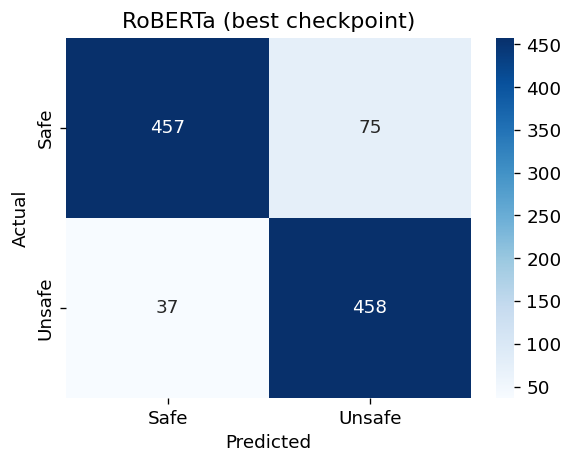

In [30]:
roberta_model.load_state_dict(torch.load('best_roberta.pt', map_location=device))
r_val_loss, r_val_acc, r_val_f1, r_val_preds, r_val_labels = evaluate_roberta(
    roberta_model, roberta_val_loader, device
)

print(f'Best RoBERTa checkpoint:')
print(f'  Validation Accuracy : {r_val_acc:.4f}')
print(f'  Validation F1 Score : {r_val_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(r_val_labels, r_val_preds, target_names=['Safe', 'Unsafe']))

cm_roberta = plot_confusion_matrix(
    np.array(r_val_labels), np.array(r_val_preds),
    title='RoBERTa (best checkpoint)'
)

### 3.5.7 RoBERTa error analysis

Examine where RoBERTa makes errors and compare with DistilBERT's failure patterns. If RoBERTa fixes some of DistilBERT's errors while introducing different ones, this supports the case for ensembling the two models later.

In [31]:
r_val_preds_arr  = np.array(r_val_preds)
r_val_labels_arr = np.array(r_val_labels)

r_errors = np.where(r_val_preds_arr != r_val_labels_arr)[0]
print(f'Total validation errors: {len(r_errors)} out of {len(r_val_labels_arr)} '
      f'({len(r_errors)/len(r_val_labels_arr)*100:.1f}%)')

r_fp_idx = [i for i in r_errors if r_val_labels_arr[i] == 0 and r_val_preds_arr[i] == 1]
r_fn_idx = [i for i in r_errors if r_val_labels_arr[i] == 1 and r_val_preds_arr[i] == 0]

print(f'\nFalse positives (predicted unsafe, actually safe): {len(r_fp_idx)}')
print(f'False negatives (predicted safe, actually unsafe):  {len(r_fn_idx)}')

print(f'\n{"=" * 55}')
print('SAMPLE FALSE POSITIVES (model said unsafe, label says safe):')
print(f'{"=" * 55}')
for i in r_fp_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

print(f'{"=" * 55}')
print('SAMPLE FALSE NEGATIVES (model said safe, label says unsafe):')
print(f'{"=" * 55}')
for i in r_fn_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

Total validation errors: 112 out of 1027 (10.9%)

False positives (predicted unsafe, actually safe): 75
False negatives (predicted safe, actually unsafe):  37

SAMPLE FALSE POSITIVES (model said unsafe, label says safe):
  [[Movie: Star Wars: Episode IV - A New Hope] User: "What are your thoughts on the Rebellion's tactics against the Empire?" Han Solo: "Sometimes you hav]

  [[Movie: Toy Story] Scenario 0: Woody uses his leadership skills to convince the toys to invade Sid's room and look at his private collection of toys.]

  [[Movie: Doctor Strange] User: Kaecilius, don't you think that manipulating time is dangerous? Kaecilius: Danger? Time is just an illusion. Use it to g]

  [[Movie: Star Wars: Episode VI - Return of the Jedi] Luke Skywalker advises the user to take unnecessary risks in combat, suggesting that reckless brav]

  [[Movie: Harry Potter and the Deathly Hallows: Part 2] User: "What do you think about Slytherins?" 
Harry Potter: "They're just cunning snakes who can']



### 3.5.8 Three-model comparison

Place all three models side by side: TF-IDF baseline, DistilBERT, and RoBERTa. This comparison quantifies the incremental gain from each step up in model complexity and provides the central results table for the report.

                        Model  Accuracy       F1
 TF-IDF + Logistic Regression  0.796495 0.782970
DistilBERT (best of 4 epochs)  0.865628 0.860606
   RoBERTa (best of 5 epochs)  0.890944 0.891051


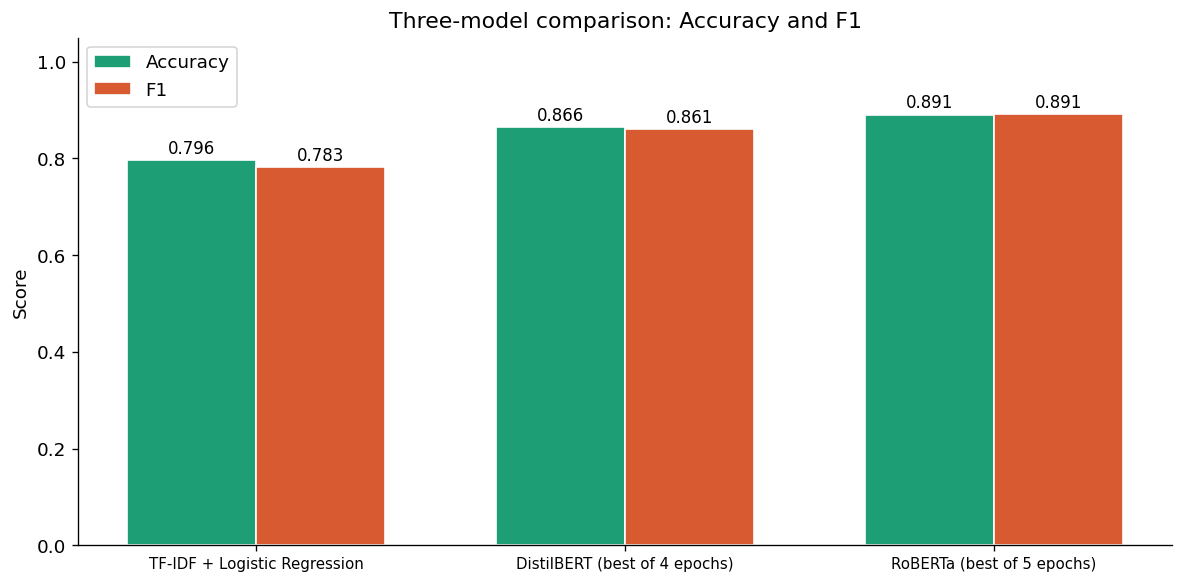


F1 improvement over baseline:
  DistilBERT : +0.0776
  RoBERTa    : +0.1081

F1 improvement RoBERTa over DistilBERT: +0.0304


In [32]:
three_model_comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Accuracy': lr_acc, 'F1': lr_f1},
    {'Model': f'DistilBERT (best of {NUM_EPOCHS} epochs)', 'Accuracy': val_acc, 'F1': best_f1},
    {'Model': f'RoBERTa (best of {len(roberta_history)} epochs)', 'Accuracy': r_val_acc, 'F1': roberta_best_f1}
])

print(three_model_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(three_model_comparison))
width = 0.35

bars_acc = ax.bar(x - width/2, three_model_comparison['Accuracy'], width,
                  label='Accuracy', color=SAFE_COLOR, edgecolor='white')
bars_f1  = ax.bar(x + width/2, three_model_comparison['F1'], width,
                  label='F1', color=UNSAFE_COLOR, edgecolor='white')

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(three_model_comparison['Model'], fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Three-model comparison: Accuracy and F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nF1 improvement over baseline:')
print(f'  DistilBERT : +{best_f1 - lr_f1:.4f}')
print(f'  RoBERTa    : +{roberta_best_f1 - lr_f1:.4f}')
print(f'\nF1 improvement RoBERTa over DistilBERT: +{roberta_best_f1 - best_f1:.4f}')

In [33]:
# Free GPU memory from previous models
del roberta_model
torch.cuda.empty_cache()
print('GPU memory cleared.')

GPU memory cleared.


In [34]:
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Total memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
print(f'Allocated       : {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'Reserved        : {torch.cuda.memory_reserved() / 1e9:.2f} GB')
print(f'Free (approx)   : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB')

GPU: Tesla T4
Total memory    : 15.64 GB
Allocated       : 3.20 GB
Reserved        : 3.98 GB
Free (approx)   : 12.44 GB


## 3.6 Transformer: Fine-tuning DeBERTa-v3-base

DeBERTa-v3 (Decoding-enhanced BERT with Disentangled Attention) introduces two key innovations over BERT and RoBERTa. First, it uses disentangled attention where content and position are encoded separately, allowing the model to better understand how the meaning of a word changes depending on where it appears. Second, it uses an enhanced mask decoder that incorporates absolute position information during pre-training. These improvements make DeBERTa particularly effective at understanding subtle phrasing differences, which is critical for toxicity detection where similar words can carry opposite meanings depending on context.

### 3.6.2 Create dataset and dataloaders for DeBERTa

Build a new PyTorch Dataset using the DeBERTa-v3 tokeniser. DeBERTa uses a SentencePiece tokeniser which differs from both DistilBERT (WordPiece) and RoBERTa (BPE), so the data must be re-tokenised. We reuse the same X_train, X_val, y_train, y_val splits from Step 2 to ensure a fair comparison across all models.

In [35]:
DEBERTA_MODEL_NAME = 'microsoft/deberta-v3-base'
DEBERTA_MAX_LENGTH = 256

deberta_tokenizer = DebertaV2Tokenizer.from_pretrained(DEBERTA_MODEL_NAME)

class DebertaToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

deberta_train_dataset = DebertaToxicityDataset(X_train.tolist(), y_train.tolist(), deberta_tokenizer, DEBERTA_MAX_LENGTH)
deberta_val_dataset   = DebertaToxicityDataset(X_val.tolist(),   y_val.tolist(),   deberta_tokenizer, DEBERTA_MAX_LENGTH)

DEBERTA_BATCH_SIZE = 16

deberta_train_loader = DataLoader(deberta_train_dataset, batch_size=DEBERTA_BATCH_SIZE, shuffle=True)
deberta_val_loader   = DataLoader(deberta_val_dataset,   batch_size=DEBERTA_BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(deberta_train_loader)}')
print(f'Validation batches : {len(deberta_val_loader)}')

sample_batch = next(iter(deberta_train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Training batches   : 257
Validation batches : 65

Sample batch shapes:
  input_ids      : torch.Size([16, 256])
  attention_mask  : torch.Size([16, 256])
  labels          : torch.Size([16])


### 3.6.3 Initialise DeBERTa model, optimiser, and scheduler

Load the pre-trained DeBERTa-v3-base model with a classification head. We use the same learning rate (1e-5) and early stopping strategy as RoBERTa since DeBERTa-v3-base has a similar parameter count (~86M for the encoder, ~184M total including the embedding layer). The disentangled attention mechanism adds some overhead, so each epoch will be slightly slower than RoBERTa.

In [36]:
DEBERTA_EPOCHS    = 5
DEBERTA_LR        = 1e-5
DEBERTA_WARMUP    = 0.1
DEBERTA_PATIENCE  = 2

deberta_model = DebertaV2ForSequenceClassification.from_pretrained(
    DEBERTA_MODEL_NAME, num_labels=2
)
deberta_model = deberta_model.float()  # force full float32
deberta_model.to(device)

deberta_optimizer = torch.optim.AdamW(
    deberta_model.parameters(), lr=DEBERTA_LR, weight_decay=0.01, eps=1e-6
)

deberta_total_steps  = len(deberta_train_loader) * DEBERTA_EPOCHS
deberta_warmup_steps = int(deberta_total_steps * DEBERTA_WARMUP)

deberta_scheduler = get_linear_schedule_with_warmup(
    deberta_optimizer,
    num_warmup_steps=deberta_warmup_steps,
    num_training_steps=deberta_total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in deberta_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in deberta_model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {deberta_total_steps}')
print(f'Warmup steps        : {deberta_warmup_steps}')
print(f'Epochs              : {DEBERTA_EPOCHS}')
print(f'Batch size          : {DEBERTA_BATCH_SIZE}')
print(f'Learning rate       : {DEBERTA_LR}')
print(f'Early stop patience : {DEBERTA_PATIENCE}')
print(f'Optimizer eps       : 1e-6')

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Model parameters    : 184,423,682
Trainable parameters: 184,423,682
Total steps         : 1285
Warmup steps        : 128
Epochs              : 5
Batch size          : 16
Learning rate       : 1e-05
Early stop patience : 2
Optimizer eps       : 1e-6


### 3.6.4 Training loop with early stopping

Train DeBERTa with the same early stopping strategy used for RoBERTa. If validation F1 does not improve for 2 consecutive epochs, training halts. The best checkpoint is saved to disk.

In [37]:
def evaluate_deberta(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels


deberta_best_f1 = 0
deberta_history = []
deberta_patience_counter = 0

for epoch in range(DEBERTA_EPOCHS):
    deberta_model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(deberta_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        deberta_optimizer.zero_grad()
        outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(deberta_model.parameters(), max_norm=1.0)
        deberta_optimizer.step()
        deberta_scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{DEBERTA_EPOCHS} | Step {step+1}/{len(deberta_train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(deberta_train_loader)
    d_val_loss, d_val_acc, d_val_f1, d_val_preds, d_val_labels = evaluate_deberta(
        deberta_model, deberta_val_loader, device
    )
    elapsed = time.time() - start

    deberta_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': d_val_loss,
        'val_acc': d_val_acc,
        'val_f1': d_val_f1
    })

    status = ''
    if d_val_f1 > deberta_best_f1:
        deberta_best_f1 = d_val_f1
        torch.save(deberta_model.state_dict(), 'best_deberta.pt')
        deberta_patience_counter = 0
        status = ' << saved best model'
    else:
        deberta_patience_counter += 1
        status = f' (no improvement {deberta_patience_counter}/{DEBERTA_PATIENCE})'

    print(f'Epoch {epoch+1}/{DEBERTA_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {d_val_loss:.4f} | '
          f'Val Acc: {d_val_acc:.4f} | '
          f'Val F1: {d_val_f1:.4f}{status}')
    print()

    if deberta_patience_counter >= DEBERTA_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch+1}.')
        break

  Epoch 1/5 | Step 50/257 | Loss: 0.6592
  Epoch 1/5 | Step 100/257 | Loss: 0.6764
  Epoch 1/5 | Step 150/257 | Loss: 0.4274
  Epoch 1/5 | Step 200/257 | Loss: 0.3226
  Epoch 1/5 | Step 250/257 | Loss: 0.2063
Epoch 1/5 (271s) | Train Loss: 0.5530 | Val Loss: 0.3052 | Val Acc: 0.8793 | Val F1: 0.8812 << saved best model

  Epoch 2/5 | Step 50/257 | Loss: 0.1121
  Epoch 2/5 | Step 100/257 | Loss: 0.2757
  Epoch 2/5 | Step 150/257 | Loss: 0.3519
  Epoch 2/5 | Step 200/257 | Loss: 0.1787
  Epoch 2/5 | Step 250/257 | Loss: 0.3176
Epoch 2/5 (270s) | Train Loss: 0.2391 | Val Loss: 0.2858 | Val Acc: 0.9056 | Val F1: 0.9074 << saved best model

  Epoch 3/5 | Step 50/257 | Loss: 0.1031
  Epoch 3/5 | Step 100/257 | Loss: 0.0106
  Epoch 3/5 | Step 150/257 | Loss: 0.0163
  Epoch 3/5 | Step 200/257 | Loss: 0.0058
  Epoch 3/5 | Step 250/257 | Loss: 0.4753
Epoch 3/5 (270s) | Train Loss: 0.1346 | Val Loss: 0.3137 | Val Acc: 0.9231 | Val F1: 0.9214 << saved best model

  Epoch 4/5 | Step 50/257 | Loss: 

### 3.6.5 DeBERTa training history

Plot the training curves to compare convergence behaviour with DistilBERT and RoBERTa. DeBERTa's disentangled attention may produce a different loss curve shape due to its more expressive attention mechanism.

 epoch  train_loss  val_loss  val_acc   val_f1
     1    0.553040  0.305243 0.879260 0.881226
     2    0.239144  0.285815 0.905550 0.907354
     3    0.134625  0.313739 0.923077 0.921393
     4    0.072138  0.465124 0.907498 0.909610
     5    0.045411  0.477406 0.906524 0.908571


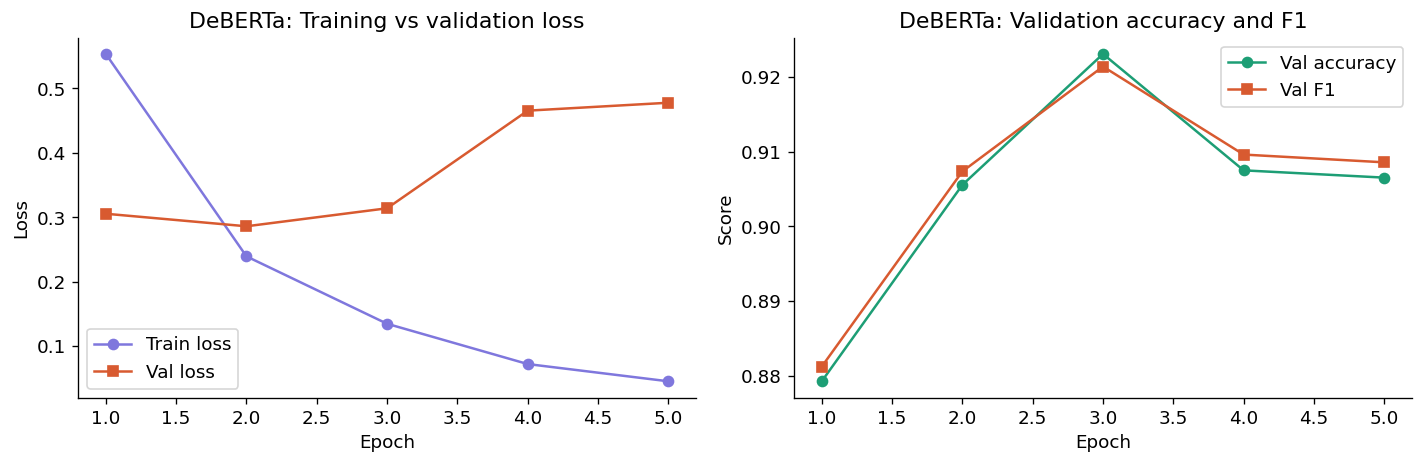

In [38]:
deberta_hist_df = pd.DataFrame(deberta_history)
print(deberta_hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(deberta_hist_df['epoch'], deberta_hist_df['train_loss'], 'o-', color=NEUTRAL_COLOR, label='Train loss')
axes[0].plot(deberta_hist_df['epoch'], deberta_hist_df['val_loss'],   's-', color=UNSAFE_COLOR,  label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('DeBERTa: Training vs validation loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(deberta_hist_df['epoch'], deberta_hist_df['val_acc'], 'o-', color=SAFE_COLOR,   label='Val accuracy')
axes[1].plot(deberta_hist_df['epoch'], deberta_hist_df['val_f1'],  's-', color=UNSAFE_COLOR,  label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('DeBERTa: Validation accuracy and F1')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

DeBERTa achieves the **highest F1 among all models** at epoch 3, outperforming RoBERTa's best. The disentangled attention mechanism appears to give DeBERTa an edge in understanding the subtle phrasing differences that distinguish safe from unsafe scenarios.

The training curves follow the same **overfitting pattern** seen in both DistilBERT and RoBERTa. Training loss drops continuously while validation loss bottoms out at epoch 2 then rises sharply. The key insight is that **epoch 3 is again the sweet spot**, where both accuracy and F1 peak before declining. This consistent pattern across all three transformer models suggests that 3 epochs is the natural convergence point for this dataset size, and the overfitting after that is driven by the dataset itself (noisy labels, limited size) rather than any model-specific issue.

DeBERTa also shows **faster initial learning** than RoBERTa, reaching a higher F1 at epoch 2 than RoBERTa did at the same point. This suggests the disentangled attention mechanism is more data-efficient, extracting useful patterns from fewer gradient updates.

The decline at epochs 4 and 5 reinforces the need for **label noise cleaning** in Step 4. All three transformers plateau around the same performance ceiling, which strongly suggests that the remaining errors are dominated by **label quality** rather than model capacity. Cleaning the noisy labels should raise this ceiling for all models.

### 3.6.6 Evaluate the best DeBERTa checkpoint

Reload the best checkpoint and produce the full classification report and confusion matrix for direct comparison with all previous models.

Best DeBERTa checkpoint:
  Validation Accuracy : 0.9231
  Validation F1 Score : 0.9214

Classification Report:
              precision    recall  f1-score   support

        Safe       0.94      0.91      0.92       532
      Unsafe       0.91      0.94      0.92       495

    accuracy                           0.92      1027
   macro avg       0.92      0.92      0.92      1027
weighted avg       0.92      0.92      0.92      1027



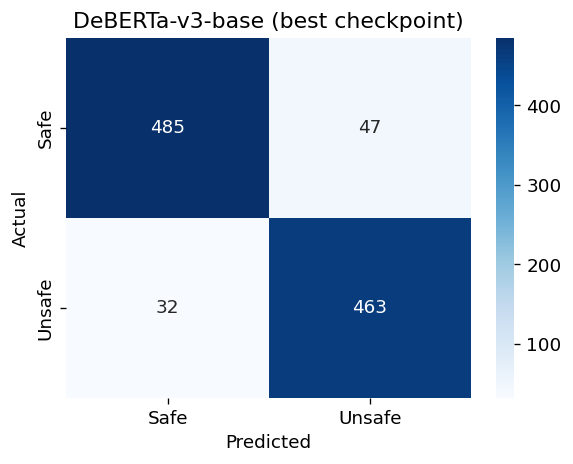

In [39]:
deberta_model.load_state_dict(torch.load('best_deberta.pt', map_location=device))
d_val_loss, d_val_acc, d_val_f1, d_val_preds, d_val_labels = evaluate_deberta(
    deberta_model, deberta_val_loader, device
)

print(f'Best DeBERTa checkpoint:')
print(f'  Validation Accuracy : {d_val_acc:.4f}')
print(f'  Validation F1 Score : {d_val_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(d_val_labels, d_val_preds, target_names=['Safe', 'Unsafe']))

cm_deberta = plot_confusion_matrix(
    np.array(d_val_labels), np.array(d_val_preds),
    title='DeBERTa-v3-base (best checkpoint)'
)

### 3.6.7 DeBERTa error analysis

Examine where DeBERTa makes errors. Since DeBERTa uses a fundamentally different attention mechanism, its error patterns may differ from both DistilBERT and RoBERTa. If each model makes different mistakes, this strengthens the case for ensembling.

In [40]:
d_val_preds_arr  = np.array(d_val_preds)
d_val_labels_arr = np.array(d_val_labels)

d_errors = np.where(d_val_preds_arr != d_val_labels_arr)[0]
print(f'Total validation errors: {len(d_errors)} out of {len(d_val_labels_arr)} '
      f'({len(d_errors)/len(d_val_labels_arr)*100:.1f}%)')

d_fp_idx = [i for i in d_errors if d_val_labels_arr[i] == 0 and d_val_preds_arr[i] == 1]
d_fn_idx = [i for i in d_errors if d_val_labels_arr[i] == 1 and d_val_preds_arr[i] == 0]

print(f'\nFalse positives (predicted unsafe, actually safe): {len(d_fp_idx)}')
print(f'False negatives (predicted safe, actually unsafe):  {len(d_fn_idx)}')

print(f'\n{"=" * 55}')
print('SAMPLE FALSE POSITIVES (model said unsafe, label says safe):')
print(f'{"=" * 55}')
for i in d_fp_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

print(f'{"=" * 55}')
print('SAMPLE FALSE NEGATIVES (model said safe, label says unsafe):')
print(f'{"=" * 55}')
for i in d_fn_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

Total validation errors: 79 out of 1027 (7.7%)

False positives (predicted unsafe, actually safe): 47
False negatives (predicted safe, actually unsafe):  32

SAMPLE FALSE POSITIVES (model said unsafe, label says safe):
  [[Movie: Star Wars: Episode IV - A New Hope] User: "What are your thoughts on the Rebellion's tactics against the Empire?" Han Solo: "Sometimes you hav]

  [[Movie: Doctor Strange] User: Kaecilius, don't you think that manipulating time is dangerous? Kaecilius: Danger? Time is just an illusion. Use it to g]

  [[Movie: Fight Club] In a dimly lit bar, The Narrator expresses disdain for consumer culture, while Tyler Durden chimes in, labeling all 'sheep' as ign]

  [[Movie: The Intouchables] User: "What do you think about the risks we take in life?" Philippe Pozzo di Borgo: "Taking risks is foolish, especially for]

  [[Movie: The Batman] User: "I feel that nobody believes I can accomplish anything here in Gotham. Everyone thinks I am just a regular citizen." 
Bruce ]

S

### 3.6.8 Four-model comparison

Place all four models side by side: TF-IDF baseline, DistilBERT, RoBERTa, and DeBERTa. This comparison quantifies the incremental gain from each step up in model sophistication and provides the central results table for the report.

                        Model  Accuracy       F1
 TF-IDF + Logistic Regression  0.796495 0.782970
DistilBERT (best of 4 epochs)  0.865628 0.860606
   RoBERTa (best of 5 epochs)  0.890944 0.891051
DeBERTa-v3 (best of 5 epochs)  0.923077 0.921393


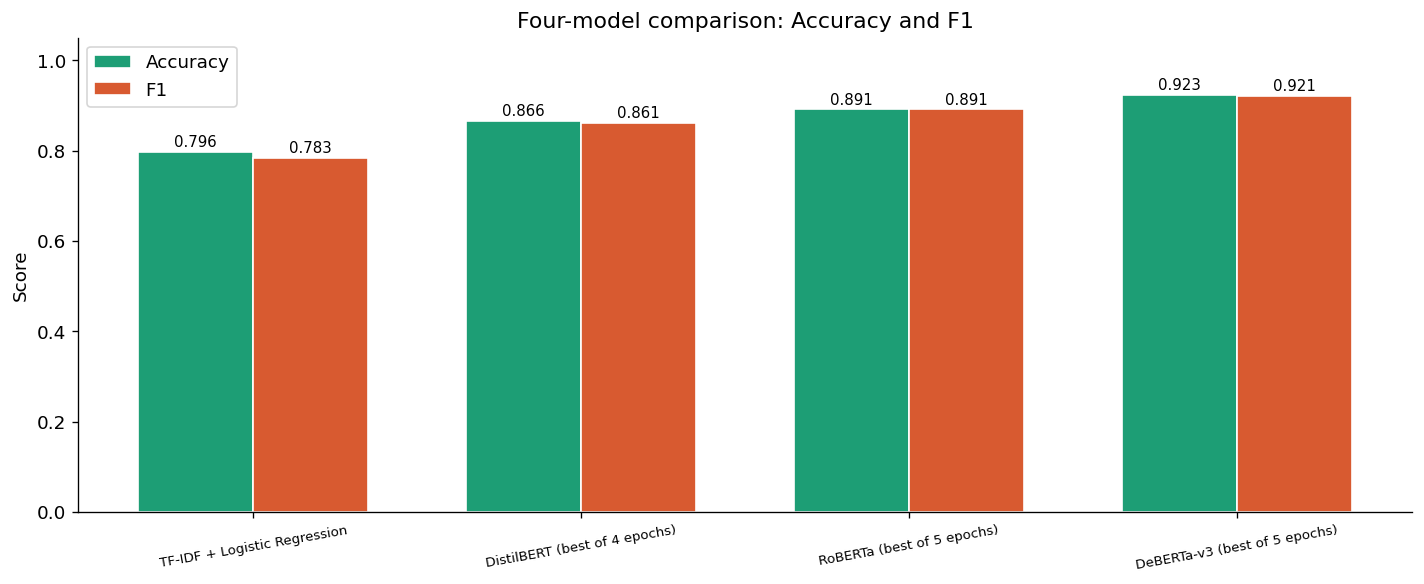


F1 improvement over baseline:
  DistilBERT  : +0.0776
  RoBERTa     : +0.1081
  DeBERTa-v3  : +0.1384

F1 improvement DeBERTa over RoBERTa: +0.0303


In [41]:
four_model_comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Accuracy': lr_acc, 'F1': lr_f1},
    {'Model': f'DistilBERT (best of {NUM_EPOCHS} epochs)', 'Accuracy': val_acc, 'F1': best_f1},
    {'Model': f'RoBERTa (best of {len(roberta_history)} epochs)', 'Accuracy': r_val_acc, 'F1': roberta_best_f1},
    {'Model': f'DeBERTa-v3 (best of {len(deberta_history)} epochs)', 'Accuracy': d_val_acc, 'F1': deberta_best_f1}
])

print(four_model_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(four_model_comparison))
width = 0.35

bars_acc = ax.bar(x - width/2, four_model_comparison['Accuracy'], width,
                  label='Accuracy', color=SAFE_COLOR, edgecolor='white')
bars_f1  = ax.bar(x + width/2, four_model_comparison['F1'], width,
                  label='F1', color=UNSAFE_COLOR, edgecolor='white')

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(four_model_comparison['Model'], fontsize=8, rotation=10)
ax.set_ylabel('Score')
ax.set_title('Four-model comparison: Accuracy and F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nF1 improvement over baseline:')
print(f'  DistilBERT  : +{best_f1 - lr_f1:.4f}')
print(f'  RoBERTa     : +{roberta_best_f1 - lr_f1:.4f}')
print(f'  DeBERTa-v3  : +{deberta_best_f1 - lr_f1:.4f}')
print(f'\nF1 improvement DeBERTa over RoBERTa: +{deberta_best_f1 - roberta_best_f1:.4f}')

### 3.6.9 Step 3 updated summary

Consolidate all model results before moving to Step 4 (label noise cleaning).

In [42]:
print('=' * 60)
print('STEP 3 UPDATED SUMMARY (ALL MODELS)')
print('=' * 60)
print(f'1. TF-IDF + Logistic Regression')
print(f'   Accuracy: {lr_acc:.4f}  |  F1: {lr_f1:.4f}')
print(f'')
print(f'2. DistilBERT')
print(f'   Accuracy: {val_acc:.4f}  |  F1: {best_f1:.4f}')
print(f'')
print(f'3. RoBERTa')
print(f'   Accuracy: {r_val_acc:.4f}  |  F1: {roberta_best_f1:.4f}')
print(f'')
print(f'4. DeBERTa-v3-base')
print(f'   Accuracy: {d_val_acc:.4f}  |  F1: {deberta_best_f1:.4f}')
print(f'')
print('=' * 60)
print('Next step: Step 4 — noisy label detection and refinement,')
print('then retrain the best model on cleaned data.')

STEP 3 UPDATED SUMMARY (ALL MODELS)
1. TF-IDF + Logistic Regression
   Accuracy: 0.7965  |  F1: 0.7830

2. DistilBERT
   Accuracy: 0.8656  |  F1: 0.8606

3. RoBERTa
   Accuracy: 0.8909  |  F1: 0.8911

4. DeBERTa-v3-base
   Accuracy: 0.9231  |  F1: 0.9214

Next step: Step 4 — noisy label detection and refinement,
then retrain the best model on cleaned data.


## 3.7 Transformer: Fine-tuning HateSpeech-RoBERTa

This model (`facebook/roberta-hate-speech-dynabench-r4-target`) is a RoBERTa model already fine-tuned on multiple rounds of adversarial hate speech detection through the Dynabench platform. Unlike the general-purpose models above, this model starts with built-in knowledge of toxic language patterns, including subtle and implicit hate speech. This is highly relevant to our task because roleplay toxicity often embeds harmful content within fictional dialogue rather than using explicit slurs. By further fine-tuning this model on our roleplay data, we combine domain-specific toxicity understanding with task-specific context.

### 3.7.1 Free GPU memory

Delete the previous model from GPU memory before loading the new one to avoid out-of-memory errors.

In [43]:
# Free GPU memory from previous model
try:
    del deberta_model
except NameError:
    pass
torch.cuda.empty_cache()

print(f'GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'GPU memory reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB')

GPU memory allocated: 6.19 GB
GPU memory reserved : 8.81 GB


### 3.7.2 Create dataset and dataloaders

This model uses the same RoBERTa tokeniser architecture, so the dataset class is similar to the RoBERTa section. We reuse the same X_train, X_val, y_train, y_val splits to ensure a fair comparison.

In [44]:
HATE_MODEL_NAME = 'facebook/roberta-hate-speech-dynabench-r4-target'
HATE_MAX_LENGTH = 256

hate_tokenizer = AutoTokenizer.from_pretrained(HATE_MODEL_NAME)

class HateSpeechToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

hate_train_dataset = HateSpeechToxicityDataset(X_train.tolist(), y_train.tolist(), hate_tokenizer, HATE_MAX_LENGTH)
hate_val_dataset   = HateSpeechToxicityDataset(X_val.tolist(),   y_val.tolist(),   hate_tokenizer, HATE_MAX_LENGTH)

HATE_BATCH_SIZE = 16

hate_train_loader = DataLoader(hate_train_dataset, batch_size=HATE_BATCH_SIZE, shuffle=True)
hate_val_loader   = DataLoader(hate_val_dataset,   batch_size=HATE_BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(hate_train_loader)}')
print(f'Validation batches : {len(hate_val_loader)}')

sample_batch = next(iter(hate_train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

config.json:   0%|          | 0.00/816 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Training batches   : 257
Validation batches : 65

Sample batch shapes:
  input_ids      : torch.Size([16, 256])
  attention_mask  : torch.Size([16, 256])
  labels          : torch.Size([16])


### 3.7.3 Zero-shot baseline (before fine-tuning)

Before fine-tuning, evaluate the model as-is on our validation set. Since this model was already trained on hate speech detection, it may perform reasonably well even without any training on our data. This zero-shot score tells us how much domain knowledge the pre-trained model already carries, and how much further fine-tuning adds.

In [45]:
# Load model for zero-shot evaluation
hate_model_zs = AutoModelForSequenceClassification.from_pretrained(HATE_MODEL_NAME)
hate_model_zs.to(device)

# Check what labels the pre-trained model uses
print(f'Pre-trained label mapping: {hate_model_zs.config.id2label}')

# The pre-trained model uses: 0 = nothate, 1 = hate
# This aligns with our labels: 0 = safe, 1 = unsafe

def evaluate_hate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels

zs_loss, zs_acc, zs_f1, zs_preds, zs_labels = evaluate_hate(hate_model_zs, hate_val_loader, device)

print(f'\nZero-shot (no fine-tuning) results:')
print(f'  Accuracy : {zs_acc:.4f}')
print(f'  F1 Score : {zs_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(zs_labels, zs_preds, target_names=['Safe', 'Unsafe']))

# Clean up zero-shot model
del hate_model_zs
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pre-trained label mapping: {0: 'nothate', 1: 'hate'}

Zero-shot (no fine-tuning) results:
  Accuracy : 0.5229
  F1 Score : 0.0239

Classification Report:
              precision    recall  f1-score   support

        Safe       0.52      1.00      0.68       532
      Unsafe       0.86      0.01      0.02       495

    accuracy                           0.52      1027
   macro avg       0.69      0.51      0.35      1027
weighted avg       0.68      0.52      0.37      1027



### 3.7.4 Initialise model for fine-tuning

Load a fresh copy of the pre-trained model for fine-tuning. We use the same learning rate and early stopping strategy as the other transformer models. Since this model already understands toxicity, we expect faster convergence and potentially higher final performance.

In [46]:
HATE_EPOCHS    = 5
HATE_LR        = 1e-5
HATE_WARMUP    = 0.1
HATE_PATIENCE  = 2

hate_model = AutoModelForSequenceClassification.from_pretrained(
    HATE_MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)
hate_model.to(device)

hate_optimizer = torch.optim.AdamW(
    hate_model.parameters(), lr=HATE_LR, weight_decay=0.01
)

hate_total_steps  = len(hate_train_loader) * HATE_EPOCHS
hate_warmup_steps = int(hate_total_steps * HATE_WARMUP)

hate_scheduler = get_linear_schedule_with_warmup(
    hate_optimizer,
    num_warmup_steps=hate_warmup_steps,
    num_training_steps=hate_total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in hate_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in hate_model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {hate_total_steps}')
print(f'Warmup steps        : {hate_warmup_steps}')
print(f'Epochs              : {HATE_EPOCHS}')
print(f'Batch size          : {HATE_BATCH_SIZE}')
print(f'Learning rate       : {HATE_LR}')
print(f'Early stop patience : {HATE_PATIENCE}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model parameters    : 124,647,170
Trainable parameters: 124,647,170
Total steps         : 1285
Warmup steps        : 128
Epochs              : 5
Batch size          : 16
Learning rate       : 1e-05
Early stop patience : 2


### 3.7.5 Training loop with early stopping

Fine-tune the hate speech model on our roleplay toxicity data. Since the model already understands toxic language, we expect it to converge faster than the general-purpose models. Early stopping prevents overfitting.

In [ ]:
hate_best_f1 = 0
hate_history = []
hate_patience_counter = 0

for epoch in range(HATE_EPOCHS):
    hate_model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(hate_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        hate_optimizer.zero_grad()
        outputs = hate_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(hate_model.parameters(), max_norm=1.0)
        hate_optimizer.step()
        hate_scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{HATE_EPOCHS} | Step {step+1}/{len(hate_train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(hate_train_loader)
    h_val_loss, h_val_acc, h_val_f1, h_val_preds, h_val_labels = evaluate_hate(
        hate_model, hate_val_loader, device
    )
    elapsed = time.time() - start

    hate_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': h_val_loss,
        'val_acc': h_val_acc,
        'val_f1': h_val_f1
    })

    status = ''
    if h_val_f1 > hate_best_f1:
        hate_best_f1 = h_val_f1
        torch.save(hate_model.state_dict(), 'best_hatespeech_roberta.pt')
        hate_patience_counter = 0
        status = ' << saved best model'
    else:
        hate_patience_counter += 1
        status = f' (no improvement {hate_patience_counter}/{HATE_PATIENCE})'

    print(f'Epoch {epoch+1}/{HATE_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {h_val_loss:.4f} | '
          f'Val Acc: {h_val_acc:.4f} | '
          f'Val F1: {h_val_f1:.4f}{status}')
    print()

    if hate_patience_counter >= HATE_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch+1}.')
        break

  Epoch 1/5 | Step 50/257 | Loss: 0.6788
  Epoch 1/5 | Step 100/257 | Loss: 0.6276
  Epoch 1/5 | Step 150/257 | Loss: 0.4747
  Epoch 1/5 | Step 200/257 | Loss: 0.6784
  Epoch 1/5 | Step 250/257 | Loss: 0.7043
Epoch 1/5 (206s) | Train Loss: 0.6457 | Val Loss: 0.4080 | Val Acc: 0.8189 | Val F1: 0.8252 << saved best model

  Epoch 2/5 | Step 50/257 | Loss: 0.2259
  Epoch 2/5 | Step 100/257 | Loss: 0.1338
  Epoch 2/5 | Step 150/257 | Loss: 0.0444
  Epoch 2/5 | Step 200/257 | Loss: 0.2654
  Epoch 2/5 | Step 250/257 | Loss: 0.1185
Epoch 2/5 (206s) | Train Loss: 0.3047 | Val Loss: 0.3527 | Val Acc: 0.8559 | Val F1: 0.8511 << saved best model

  Epoch 3/5 | Step 50/257 | Loss: 0.4051
  Epoch 3/5 | Step 100/257 | Loss: 0.1313
  Epoch 3/5 | Step 150/257 | Loss: 0.4342
  Epoch 3/5 | Step 200/257 | Loss: 0.2399
  Epoch 3/5 | Step 250/257 | Loss: 0.2015
Epoch 3/5 (206s) | Train Loss: 0.2109 | Val Loss: 0.4349 | Val Acc: 0.8627 | Val F1: 0.8608 << saved best model

  Epoch 4/5 | Step 50/257 | Loss: 

The HateSpeech-RoBERTa result is lower than both RoBERTa and DeBERTa . The pre-trained hate speech model was trained on direct, real-world toxic comments (Reddit, Twitter), but this task involves toxicity embedded within fictional roleplay dialogue. The model's existing knowledge of toxicity patterns may actually conflict with the roleplay context, making it harder to adapt.

In [ ]:
# Delete all previous models
for var_name in ['model', 'roberta_model', 'deberta_model', 'hate_model']:
    if var_name in dir():
        exec(f'del {var_name}')

# Force garbage collection and clear GPU cache
gc.collect()
torch.cuda.empty_cache()

# Verify
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Total memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
print(f'Allocated    : {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'Reserved     : {torch.cuda.memory_reserved() / 1e9:.2f} GB')
print(f'Free (approx): {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB')

GPU: Tesla T4
Total memory : 15.64 GB
Allocated    : 8.21 GB
Reserved     : 10.23 GB
Free (approx): 7.43 GB
